# Customer & Product Segmentation

Notebook này giải bài toán segmentation theo 3 lớp phân tích:

1. **Phân cụm Khách hàng bằng RFM & K-Means**
2. **Phân nhóm Sản phẩm bằng Profit-Volume Matrix**
3. **Cross-Mapping: Khách hàng x Sản phẩm x Kênh/Khuyến mãi**

**Quan sát → Insights → Gợi ý hành động**.

In [1]:
# 0. Setup
from pathlib import Path
from collections import Counter
import os
import warnings

os.environ.setdefault("LOKY_MAX_CPU_COUNT", str(os.cpu_count() or 1))
os.environ.setdefault("OMP_NUM_THREADS", "1")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

try:
    from sklearn.preprocessing import StandardScaler
    from sklearn.cluster import KMeans
    from sklearn.metrics import silhouette_score
except ImportError as exc:
    raise ImportError("Notebook cần scikit-learn để chạy K-Means. Cài bằng: pip install scikit-learn") from exc

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)
pd.options.display.float_format = "{:,.2f}".format
sns.set_theme(style="whitegrid", context="notebook")
RANDOM_STATE = 42

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists() and (PROJECT_ROOT.parent / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data" / "raw"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
OUTPUT_DIR.mkdir(exist_ok=True)
print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data folder: {DATA_DIR}")

Project root: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni
Raw data folder: d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\data\raw


In [3]:
# 0.1. Load dữ liệu raw
customers = pd.read_csv(DATA_DIR / "customers.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv", parse_dates=["order_date"])
payments = pd.read_csv(DATA_DIR / "payments.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv", low_memory=False)
products = pd.read_csv(DATA_DIR / "products.csv")
inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
promotions = pd.read_csv(DATA_DIR / "promotions.csv", parse_dates=["start_date", "end_date"])
sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

raw_shapes = pd.DataFrame({
    "table": ["customers", "orders", "payments", "order_items", "products", "inventory", "promotions", "sales"],
    "rows": [len(customers), len(orders), len(payments), len(order_items), len(products), len(inventory), len(promotions), len(sales)],
    "columns": [customers.shape[1], orders.shape[1], payments.shape[1], order_items.shape[1], products.shape[1], inventory.shape[1], promotions.shape[1], sales.shape[1]],
})
display(raw_shapes)
print("Order date range:", orders["order_date"].min().date(), "→", orders["order_date"].max().date())
display(orders["order_status"].value_counts().rename_axis("order_status").reset_index(name="orders"))

,table,rows,columns
0,customers,121930,7
1,orders,646945,8
2,payments,646945,4
3,order_items,714669,7
4,products,2412,8
5,inventory,60247,17
6,promotions,50,10
7,sales,3833,3


Order date range: 2012-07-04 → 2022-12-31


,order_status,orders
0,delivered,516716
1,cancelled,59462
2,returned,36142
3,shipped,13773
4,paid,13577
5,created,7275


## 1. Phân cụm Khách hàng bằng RFM & K-Means

Mục tiêu là chuyển hành vi mua hàng thành 3 biến lõi:

- **Recency:** số ngày kể từ lần mua gần nhất của mỗi `customer_id` đến ngày mốc của dataset.
- **Frequency:** số lượng đơn hàng thành công của mỗi khách hàng.
- **Monetary:** tổng `payment_value` khách hàng đã chi.

Để tránh nhiễu từ đơn huỷ/trả, phân tích RFM dùng các đơn có `order_status = delivered`. Ngày mốc phân tích là ngày sau `order_date` lớn nhất trong dataset.

In [4]:
# 1.1. Tạo RFM và biến khuyến mãi hỗ trợ diễn giải cụm
valid_orders = orders.loc[orders["order_status"].eq("delivered")].copy()
analysis_date = orders["order_date"].max() + pd.Timedelta(days=1)

payments_by_order = payments.groupby("order_id", as_index=False)["payment_value"].sum()

items_for_revenue = order_items.copy()
items_for_revenue["discount_amount"] = items_for_revenue["discount_amount"].fillna(0)
items_for_revenue["item_revenue"] = (
    items_for_revenue["quantity"] * items_for_revenue["unit_price"] - items_for_revenue["discount_amount"]
)
revenue_by_order = items_for_revenue.groupby("order_id", as_index=False)["item_revenue"].sum()

rfm_orders = (
    valid_orders[["order_id", "customer_id", "order_date"]]
    .merge(payments_by_order, on="order_id", how="left")
    .merge(revenue_by_order, on="order_id", how="left")
)
rfm_orders["payment_value"] = rfm_orders["payment_value"].fillna(rfm_orders["item_revenue"])

rfm = (
    rfm_orders.groupby("customer_id")
    .agg(
        last_order_date=("order_date", "max"),
        frequency=("order_id", "nunique"),
        monetary=("payment_value", "sum"),
    )
    .reset_index()
)
rfm["recency"] = (analysis_date - rfm["last_order_date"]).dt.days

items_for_discount = order_items.copy()
items_for_discount["discount_amount"] = items_for_discount["discount_amount"].fillna(0)
items_for_discount["gross_sales"] = items_for_discount["quantity"] * items_for_discount["unit_price"]
promo_cols = [col for col in ["promo_id", "promo_id_2"] if col in items_for_discount.columns]
items_for_discount["has_promo"] = items_for_discount[promo_cols].notna().any(axis=1) if promo_cols else False

order_discount = (
    items_for_discount.groupby("order_id")
    .agg(gross_sales=("gross_sales", "sum"), total_discount=("discount_amount", "sum"), promo_flag=("has_promo", "max"))
    .reset_index()
)

customer_discount = (
    valid_orders[["order_id", "customer_id"]]
    .merge(order_discount, on="order_id", how="left")
    .groupby("customer_id")
    .agg(
        gross_sales=("gross_sales", "sum"),
        total_discount=("total_discount", "sum"),
        promo_orders=("promo_flag", "sum"),
        delivered_orders=("order_id", "nunique"),
    )
    .reset_index()
)
customer_discount["discount_rate"] = (
    customer_discount["total_discount"] / customer_discount["gross_sales"]
).replace([np.inf, -np.inf], np.nan).fillna(0)
customer_discount["promo_order_rate"] = (
    customer_discount["promo_orders"] / customer_discount["delivered_orders"]
).replace([np.inf, -np.inf], np.nan).fillna(0)

rfm = rfm.merge(
    customer_discount[["customer_id", "discount_rate", "promo_order_rate"]],
    on="customer_id",
    how="left",
).fillna({"discount_rate": 0, "promo_order_rate": 0})

print(f"Analysis date: {analysis_date.date()}")
print(f"Delivered orders used: {len(valid_orders):,}")
print(f"Customers with delivered orders: {rfm['customer_id'].nunique():,}")
display(rfm[["recency", "frequency", "monetary", "discount_rate", "promo_order_rate"]].describe().T)

Analysis date: 2023-01-01
Delivered orders used: 516,716
Customers with delivered orders: 85,115


,count,mean,std,min,25%,50%,75%,max
recency,"85,115.00","1,328.20","1,029.36",1.00,396.00,"1,143.00","2,047.00","3,833.00"
frequency,"85,115.00",6.07,7.04,1.00,1.00,3.00,8.00,93.00
monetary,"85,115.00","147,073.68","179,937.43",445.65,"28,544.99","79,730.85","198,288.89","2,883,271.24"
discount_rate,"85,115.00",0.05,0.05,0.00,0.00,0.04,0.08,0.20
promo_order_rate,"85,115.00",0.38,0.32,0.00,0.00,0.35,0.50,1.00


In [5]:
# 1.2. Scale RFM và chạy K-Means
rfm_features = rfm[["recency", "frequency", "monetary"]].clip(lower=0).apply(np.log1p)
scaler = StandardScaler()
X_rfm = scaler.fit_transform(rfm_features)

silhouette_records = []
for k in range(3, 8):
    candidate = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=30)
    labels = candidate.fit_predict(X_rfm)
    silhouette_records.append({
        "k": k,
        "silhouette_sample": silhouette_score(
            X_rfm, labels, sample_size=min(10_000, len(X_rfm)), random_state=RANDOM_STATE
        ),
    })
silhouette_df = pd.DataFrame(silhouette_records)
display(silhouette_df)

# K=5 tách rõ Champions, Loyal, At Risk, Bargain Hunters và một nhóm low-engagement riêng.
N_CLUSTERS = 5
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=50)
rfm["cluster_id"] = kmeans.fit_predict(X_rfm)

cluster_profile = (
    rfm.groupby("cluster_id")
    .agg(
        customers=("customer_id", "nunique"),
        recency_mean=("recency", "mean"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        monetary_sum=("monetary", "sum"),
        discount_rate_mean=("discount_rate", "mean"),
        promo_order_rate_mean=("promo_order_rate", "mean"),
    )
    .reset_index()
)
cluster_profile["customer_share"] = cluster_profile["customers"] / cluster_profile["customers"].sum()

work = cluster_profile.copy()
work["rfm_strength"] = (
    work["recency_mean"].rank(ascending=False)
    + work["frequency_mean"].rank(ascending=True)
    + work["monetary_mean"].rank(ascending=True)
)

label_map = {}
champion_cluster = int(work.loc[work["rfm_strength"].idxmax(), "cluster_id"])
label_map[champion_cluster] = "Champions"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
bargain_pool = remaining.loc[
    (remaining["frequency_mean"] <= work["frequency_mean"].median())
    | (remaining["monetary_mean"] <= work["monetary_mean"].median())
]
bargain_row = (bargain_pool if len(bargain_pool) else remaining).sort_values(
    ["promo_order_rate_mean", "discount_rate_mean", "recency_mean"], ascending=[False, False, False]
).iloc[0]
label_map[int(bargain_row["cluster_id"])] = "Bargain Hunters"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
risk_pool = remaining.loc[remaining["monetary_mean"] >= work["monetary_mean"].median()]
risk_row = (risk_pool if len(risk_pool) else remaining).sort_values(
    ["recency_mean", "monetary_mean"], ascending=[False, False]
).iloc[0]
label_map[int(risk_row["cluster_id"])] = "At Risk / Churn"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
loyal_row = remaining.sort_values(["recency_mean", "frequency_mean"], ascending=[True, False]).iloc[0]
label_map[int(loyal_row["cluster_id"])] = "Loyal Customers"

remaining = work.loc[~work["cluster_id"].isin(label_map)].copy()
for cluster_id in remaining["cluster_id"]:
    label_map[int(cluster_id)] = "Hibernating / Low Engagement"

rfm["customer_segment"] = rfm["cluster_id"].map(label_map)
customer_segment_order = [
    "Champions",
    "Loyal Customers",
    "At Risk / Churn",
    "Bargain Hunters",
    "Hibernating / Low Engagement",
]

rfm_segment_summary = (
    rfm.groupby("customer_segment")
    .agg(
        customers=("customer_id", "nunique"),
        recency_mean=("recency", "mean"),
        frequency_mean=("frequency", "mean"),
        monetary_mean=("monetary", "mean"),
        monetary_sum=("monetary", "sum"),
        discount_rate_mean=("discount_rate", "mean"),
        promo_order_rate_mean=("promo_order_rate", "mean"),
    )
    .reset_index()
)
rfm_segment_summary["customer_share"] = rfm_segment_summary["customers"] / rfm_segment_summary["customers"].sum()
rfm_segment_summary["monetary_share"] = rfm_segment_summary["monetary_sum"] / rfm_segment_summary["monetary_sum"].sum()
rfm_segment_summary["sort_order"] = rfm_segment_summary["customer_segment"].map({v: i for i, v in enumerate(customer_segment_order)})
rfm_segment_summary = rfm_segment_summary.sort_values("sort_order").drop(columns="sort_order")

display(
    rfm_segment_summary.style.format({
        "customers": "{:,.0f}",
        "recency_mean": "{:,.1f}",
        "frequency_mean": "{:,.2f}",
        "monetary_mean": "{:,.0f}",
        "monetary_sum": "{:,.0f}",
        "discount_rate_mean": "{:.2%}",
        "promo_order_rate_mean": "{:.2%}",
        "customer_share": "{:.2%}",
        "monetary_share": "{:.2%}",
    })
)

,k,silhouette_sample
0,3,0.37
1,4,0.31
2,5,0.34
3,6,0.34
4,7,0.32


,customer_segment,customers,recency_mean,frequency_mean,monetary_mean,monetary_sum,discount_rate_mean,promo_order_rate_mean,customer_share,monetary_share
2,Champions,"12,789",201.0,18.09,"450,123","5,756,629,394",4.64%,38.25%,15.03%,45.99%
4,Loyal Customers,"9,024",219.2,3.87,"93,248","841,471,374",5.15%,39.30%,10.60%,6.72%
0,At Risk / Churn,"19,547",982.7,8.61,"212,078","4,145,491,735",4.53%,37.73%,22.97%,33.12%
1,Bargain Hunters,"17,261","2,333.4",1.16,"11,317","195,337,875",6.30%,43.66%,20.28%,1.56%
3,Hibernating / Low Engagement,"26,494","1,850.1",2.34,"59,608","1,579,245,578",4.45%,34.98%,31.13%,12.62%


**Top age_group theo customer segment**

,customer_segment,age_group,customers,share_in_segment
0,At Risk / Churn,25-34,"5,765",29.5%
1,At Risk / Churn,35-44,"5,059",25.9%
2,At Risk / Churn,45-54,"3,750",19.2%
3,Bargain Hunters,25-34,"5,189",30.1%
4,Bargain Hunters,35-44,"4,490",26.0%
5,Bargain Hunters,45-54,"3,261",18.9%
6,Champions,25-34,"3,766",29.4%
7,Champions,35-44,"3,398",26.6%
8,Champions,45-54,"2,474",19.3%
9,Hibernating / Low Engagement,25-34,"7,919",29.9%


**Top gender theo customer segment**

,customer_segment,gender,customers,share_in_segment
0,At Risk / Churn,Female,"9,537",48.8%
1,At Risk / Churn,Male,"9,281",47.5%
2,At Risk / Churn,Non-binary,729,3.7%
3,Bargain Hunters,Female,"8,392",48.6%
4,Bargain Hunters,Male,"8,178",47.4%
5,Bargain Hunters,Non-binary,691,4.0%
6,Champions,Female,"6,304",49.3%
7,Champions,Male,"5,991",46.8%
8,Champions,Non-binary,494,3.9%
9,Hibernating / Low Engagement,Female,"13,072",49.3%


**Top acquisition_channel theo customer segment**

,customer_segment,acquisition_channel,customers,share_in_segment
0,At Risk / Churn,organic_search,"5,839",29.9%
1,At Risk / Churn,social_media,"3,984",20.4%
2,At Risk / Churn,paid_search,"3,798",19.4%
3,Bargain Hunters,organic_search,"5,172",30.0%
4,Bargain Hunters,paid_search,"3,500",20.3%
5,Bargain Hunters,social_media,"3,342",19.4%
6,Champions,organic_search,"3,879",30.3%
7,Champions,paid_search,"2,618",20.5%
8,Champions,social_media,"2,518",19.7%
9,Hibernating / Low Engagement,organic_search,"7,904",29.8%


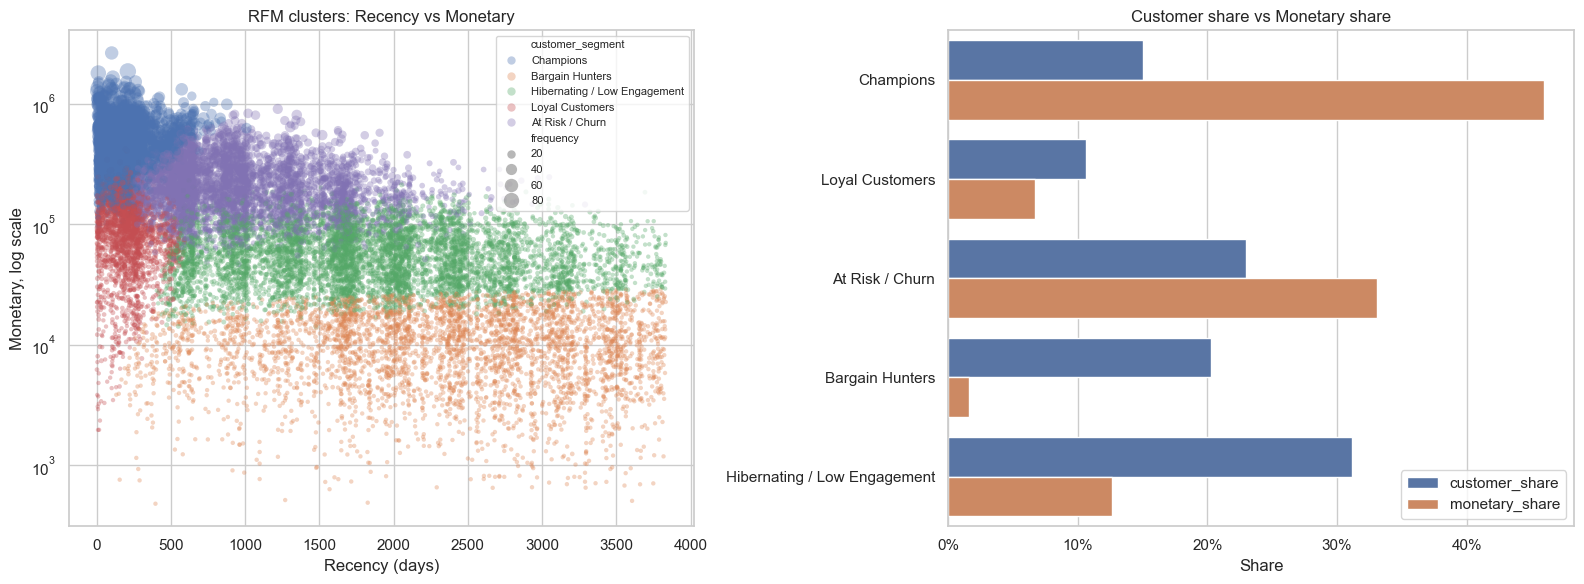

In [6]:
# 1.3. Join demographics và trực quan hoá cụm khách hàng
customer_segments = rfm[[
    "customer_id", "customer_segment", "cluster_id", "recency", "frequency", "monetary",
    "discount_rate", "promo_order_rate"
]].merge(customers, on="customer_id", how="left")

def top_share(df, group_col, target_col, n=3):
    out = df.groupby([group_col, target_col]).size().rename("customers").reset_index()
    out["share_in_segment"] = out["customers"] / out.groupby(group_col)["customers"].transform("sum")
    return out.sort_values([group_col, "customers"], ascending=[True, False]).groupby(group_col).head(n).reset_index(drop=True)

for col in ["age_group", "gender", "acquisition_channel"]:
    display(Markdown(f"**Top {col} theo customer segment**"))
    display(top_share(customer_segments, "customer_segment", col).style.format({"customers": "{:,.0f}", "share_in_segment": "{:.1%}"}))

plot_sample = customer_segments.sample(min(20_000, len(customer_segments)), random_state=RANDOM_STATE)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=plot_sample, x="recency", y="monetary", hue="customer_segment", size="frequency",
    sizes=(10, 140), alpha=0.35, linewidth=0, ax=axes[0]
)
axes[0].set_yscale("log")
axes[0].set_title("RFM clusters: Recency vs Monetary")
axes[0].set_xlabel("Recency (days)")
axes[0].set_ylabel("Monetary, log scale")
axes[0].legend(loc="upper right", fontsize=8)

summary_long = rfm_segment_summary.melt(
    id_vars="customer_segment", value_vars=["customer_share", "monetary_share"],
    var_name="metric", value_name="share"
)
sns.barplot(data=summary_long, x="share", y="customer_segment", hue="metric", order=customer_segment_order, ax=axes[1])
axes[1].set_title("Customer share vs Monetary share")
axes[1].set_xlabel("Share")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[1].legend(title="")
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Quy mô RFM:** Phân tích sử dụng **516,716 đơn delivered** và **85,115 khách hàng** có giao dịch thành công. Ngày mốc của dataset là **2023-01-01**.
  - **Cấu trúc cụm:** K-Means với `K=5` tách được các nhóm có ý nghĩa kinh doanh hơn so với ép `K=4`: **Champions** chiếm khoảng **15.0% khách** nhưng tạo gần **46.0% monetary**, còn **At Risk / Churn** chiếm **23.0% khách** và vẫn giữ khoảng **33.1% monetary lịch sử**.
  - **Bargain Hunters:** Nhóm này có `frequency_mean` khoảng **1.16 đơn/khách**, `monetary_mean` khoảng **11.3K**, nhưng có `promo_order_rate_mean` cao nhất, khoảng **44%**, đúng với hành vi săn khuyến mãi.
  - **Nhân khẩu học:** Nhóm tuổi **25-34** chiếm khoảng **29-30%**, Female khoảng **49%**, và `organic_search` khoảng **30%** ở hầu hết cụm. Demographic cơ bản chưa đủ để phân cụm tốt; RFM mới là lớp phân biệt hành vi chính.

- **Insights:**
  - **Champions là nhóm cần bảo vệ nhất:** Quy mô nhỏ hơn nhiều so với tổng tập khách nhưng đóng góp monetary vượt trội; mất nhóm này sẽ tác động doanh thu mạnh.
  - **At Risk / Churn là cơ hội win-back lớn:** Nhóm này từng mua nhiều (`frequency_mean` khoảng **8.6**, `monetary_mean` khoảng **212K**) nhưng đã lâu không quay lại (`recency_mean` gần **983 ngày**).
  - **Bargain Hunters không nên được nuôi bằng giảm giá rộng:** Promo rate cao nhưng monetary thấp, nên discount không kiểm soát dễ kéo biên lợi nhuận xuống.
  - **Hibernating / Low Engagement là vùng cần tối ưu chi phí:** Nhóm này đông nhất, hơn **31% khách**, nhưng monetary share thấp hơn nhiều so với customer share.

- **Gợi ý hành động:**
  - **Retention cho Champions:** Tạo ưu đãi độc quyền, early access, bundle sản phẩm biên lợi nhuận cao, và cảnh báo nếu recency vượt ngưỡng 90-180 ngày.
  - **Win-back cho At Risk / Churn:** Cá nhân hoá theo danh mục từng mua, đo uplift bằng holdout group thay vì gửi voucher đại trà.
  - **Quản trị khuyến mãi cho Bargain Hunters:** Chỉ cấp voucher có điều kiện như minimum basket value, giới hạn danh mục Cash Cows cần xả hàng, hoặc combo giúp tăng AOV.
  - **Không dùng demographic đơn lẻ để target:** Tuổi/giới/kênh khá giống nhau giữa các cụm, nên CRM nên ưu tiên RFM segment trước.

## 2.1. Nhóm sản phẩm theo biên lợi nhuận

#### 2.1.1. Top những loại sản phẩm có biên lợi nhuận cao nhất

## 2.2. Phân nhóm Sản phẩm theo Profit-Volume Matrix 

Bước này phân loại sản phẩm bằng 2 trục:

- **Gross Margin:** `(price - cogs) / price`
- **Sales Volume:** tổng `quantity` bán ra trong `order_items.csv`

Ngưỡng cao/thấp được đặt theo median của từng trục để tạo 4 góc phần tư: **Stars**, **Cash Cows**, **Question Marks**, **Dogs**.

| Phân khúc              | Đặc điểm (Biên LN & Sản lượng)                         | Nhận xét & Chiến lược                                                                 |
|------------------------|--------------------------------------------------------|----------------------------------------------------------------------------------------|
| Stars (Ngôi sao)       | Cao & Cao: Nằm góc trên bên phải (màu cam).           | Sản phẩm chủ lực, mang lại cả doanh thu và lợi nhuận lớn. Cần đầu tư tối đa để duy trì vị thế dẫn đầu. |
| Cash Cows (Bò sữa)     | Thấp & Cao: Nằm góc dưới bên phải (màu xanh dương).   | Sản lượng cực lớn nhưng biên lợi nhuận mỏng. Đây là nguồn tiền mặt ổn định; cần tối ưu hóa quy trình để giảm chi phí hơn nữa. |
| Question Marks (Dấu hỏi)| Cao & Thấp: Nằm góc trên bên trái (màu đỏ).          | Sản phẩm có biên lợi nhuận tốt nhưng chưa bán chạy. Cần đẩy mạnh Marketing hoặc kiểm tra lại tệp khách hàng để tăng sản lượng. |
| Dogs (Chó hoang)       | Thấp & Thấp: Nằm góc dưới bên trái (màu xanh lá).     | Hiệu quả kém về cả lợi nhuận lẫn doanh số. Nên cân nhắc loại bỏ hoặc cải tổ để tránh lãng phí nguồn lực kho bãi. |



In [ ]:
product_segments = products.copy()
product_segments["gross_margin"] = ((product_segments["price"] - product_segments["cogs"]) / product_segments["price"]).replace([np.inf, -np.inf], np.nan)

sales_volume = order_items.groupby("product_id", as_index=False)["quantity"].sum().rename(columns={"quantity": "sales_volume"})
product_segments = product_segments.merge(sales_volume, on="product_id", how="left")
product_segments["sales_volume"] = product_segments["sales_volume"].fillna(0)

margin_cutoff = product_segments["gross_margin"].median()
volume_cutoff = product_segments["sales_volume"].median()

product_segments["product_segment_pv"] = np.select(
    [
        (product_segments["gross_margin"] >= margin_cutoff) & (product_segments["sales_volume"] >= volume_cutoff),
        (product_segments["gross_margin"] < margin_cutoff) & (product_segments["sales_volume"] >= volume_cutoff),
        (product_segments["gross_margin"] >= margin_cutoff) & (product_segments["sales_volume"] < volume_cutoff),
        (product_segments["gross_margin"] < margin_cutoff) & (product_segments["sales_volume"] < volume_cutoff),
    ],
    ["Stars", "Cash Cows", "Question Marks", "Dogs"],
    default="Unclassified",
)

product_segment_summary = (
    product_segments.groupby("product_segment_pv")
    .agg(products=("product_id", "nunique"), avg_margin=("gross_margin", "mean"), total_volume=("sales_volume", "sum"), avg_volume=("sales_volume", "mean"), avg_price=("price", "mean"))
    .reset_index()
)
product_segment_summary["product_share"] = product_segment_summary["products"] / product_segment_summary["products"].sum()
product_segment_summary["volume_share"] = product_segment_summary["total_volume"] / product_segment_summary["total_volume"].sum()
product_segment_summary = product_segment_summary.sort_values("total_volume", ascending=False)

print(f"Gross margin median cutoff: {margin_cutoff:.2%}")
print(f"Sales volume median cutoff: {volume_cutoff:,.0f} units")
display(product_segment_summary.style.format({
    "products": "{:,.0f}", "avg_margin": "{:.2%}", "total_volume": "{:,.0f}",
    "avg_volume": "{:,.1f}", "avg_price": "{:,.0f}", "product_share": "{:.2%}", "volume_share": "{:.2%}",
}))

category_pv_summary = (
    product_segments.groupby(["category", "product_segment_pv"])
    .agg(products=("product_id", "nunique"), volume=("sales_volume", "sum"), avg_margin=("gross_margin", "mean"))
    .reset_index()
    .sort_values(["category", "volume"], ascending=[True, False])
)
display(category_pv_summary.groupby("category").head(3).style.format({"products": "{:,.0f}", "volume": "{:,.0f}", "avg_margin": "{:.2%}"}))

Gross margin median cutoff: 30.58%
Sales volume median cutoff: 86 units


,product_segment_pv,products,avg_margin,total_volume,avg_volume,avg_price,product_share,volume_share
0,Cash Cows,822,12.97%,"2,225,526","2,707.5","6,667",34.08%,69.26%
3,Stars,387,40.34%,"976,089","2,522.2","6,610",16.04%,30.38%
1,Dogs,384,13.14%,"7,985",20.8,"7,030",15.92%,0.25%
2,Question Marks,819,40.05%,"3,543",4.3,"1,403",33.96%,0.11%


,category,product_segment_pv,products,volume,avg_margin
0,Casual,Cash Cows,48,"83,247",13.33%
3,Casual,Stars,26,"22,788",38.89%
1,Casual,Dogs,38,852,13.56%
4,GenZ,Cash Cows,67,"94,875",11.26%
7,GenZ,Stars,27,"71,408",41.33%
5,GenZ,Dogs,17,289,12.54%
8,Outdoor,Cash Cows,248,"788,792",13.28%
11,Outdoor,Stars,114,"377,655",40.91%
9,Outdoor,Dogs,119,"2,573",13.07%
12,Streetwear,Cash Cows,459,"1,258,612",13.02%


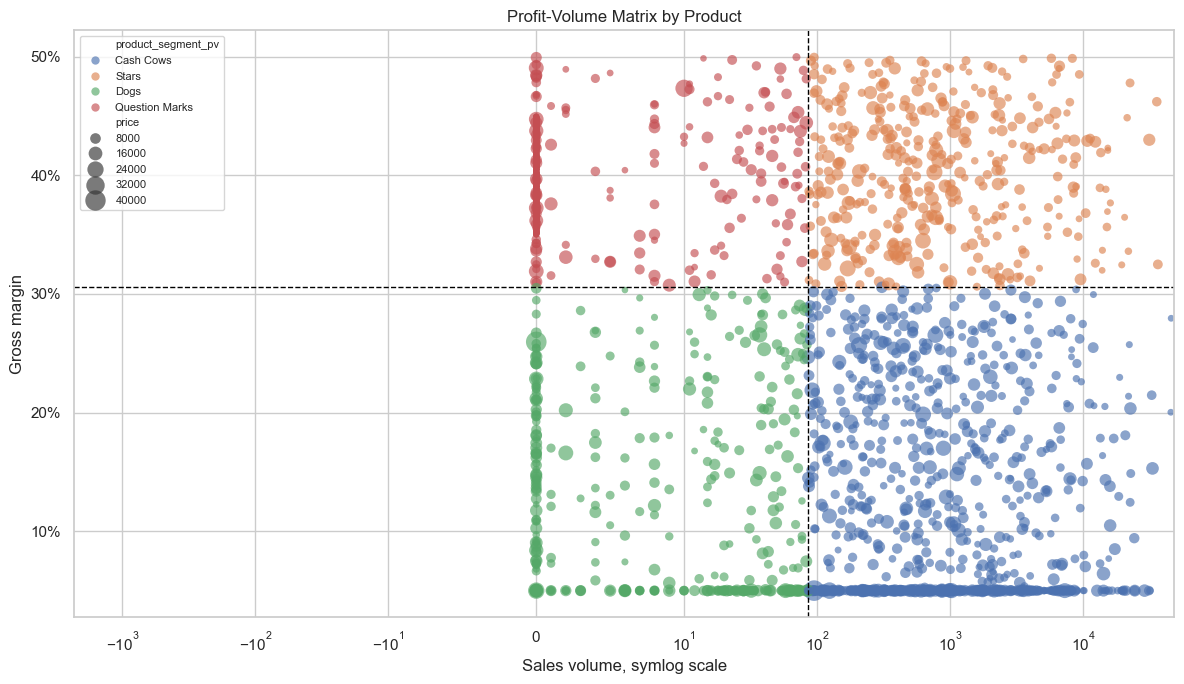

In [ ]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.scatterplot(
    data=product_segments, x="sales_volume", y="gross_margin", hue="product_segment_pv",
    size="price", sizes=(20, 220), alpha=0.65, linewidth=0, ax=ax
)
ax.axhline(margin_cutoff, color="black", linestyle="--", linewidth=1)
ax.axvline(volume_cutoff, color="black", linestyle="--", linewidth=1)
ax.set_xscale("symlog", linthresh=10)
ax.yaxis.set_major_formatter(lambda y, pos: f"{y:.0%}")
ax.set_title("Profit-Volume Matrix by Product")
ax.set_xlabel("Sales volume, symlog scale")
ax.set_ylabel("Gross margin")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

**Quan sát**

Sự tập trung của Cash Cows: Nhóm màu xanh dương (Cash Cows) có mật độ rất dày đặc ở vùng sản lượng từ $10^2$ đến $10^4$. Điều này cho thấy doanh nghiệp đang vận hành dựa trên chiến lược "số lượng lớn", chấp nhận biên lợi nhuận dưới 30% để chiếm lĩnh thị trường.

Khoảng trống sản lượng thấp: Có một dải sản phẩm (màu đỏ và xanh lá) tập trung sát vạch mức 0 trên trục sản lượng. Đây có thể là các sản phẩm mới ra mắt hoặc các mã hàng tồn kho lâu ngày không phát sinh đơn hàng đáng kể.

Kích thước bóng (Price): 

- Các bóng có kích thước lớn (giá cao) xuất hiện rải rác ở nhóm Question Marks và Stars.

- Nhóm Cash Cows và Dogs đa số là các bóng nhỏ, cho thấy các sản phẩm giá rẻ thường có xu hướng rơi vào nhóm có biên lợi nhuận thấp hơn.

Điểm bùng nổ: Ranh giới phân tách sản lượng (đường kẻ dọc) nằm ở mức khoảng 80 - 100 đơn vị. Sản phẩm nào vượt qua ngưỡng này sẽ chuyển dịch sang vùng mang lại dòng tiền chính (Stars/Cash Cows).

**Nhận xét tổng thể:**

- **Quan sát:**
  - **Ngưỡng phân loại:** Median gross margin của danh mục là khoảng **30.6%** và median sales volume là **86 units**.
  - **Cash Cows:** Có **822 sản phẩm** nhưng chiếm khoảng **69.3% tổng units bán ra**, gross margin trung bình chỉ khoảng **13%**.
  - **Stars:** Có **387 sản phẩm**, chiếm khoảng **30.4% units**, gross margin trung bình khoảng **40%**.
  - **Question Marks và Dogs:** Số SKU khá lớn (**819** và **384 sản phẩm**) nhưng tổng volume rất thấp, lần lượt khoảng **3.5K** và **8.0K units**.
  - **Theo category:** `Streetwear` và `Outdoor` là hai nguồn volume lớn nhất; `Streetwear - Cash Cows` đạt hơn **1.25M units** và `Streetwear - Stars` hơn **504K units**.

- **Insights:**
  - **Danh mục đang phụ thuộc vào Cash Cows:** Volume lớn nằm ở sản phẩm biên thấp, nên lợi nhuận dễ bị bào mòn nếu logistics, discount hoặc return tăng.
  - **Stars là đòn bẩy lợi nhuận:** Số SKU ít hơn Cash Cows nhưng margin cao và tốc độ bán tốt, cần được ưu tiên tồn kho/hiển thị/cross-sell.
  - **Question Marks chưa chứng minh được demand:** Biên lợi nhuận tốt nhưng volume quá thấp, có thể do thiếu traffic, định vị sai kênh, giá cao, hoặc sản phẩm mới chưa được kích hoạt.
  - **Dogs cần kiểm soát tồn kho:** Volume thấp và margin thấp đồng thời làm tăng rủi ro tồn kho chết.

- **Gợi ý hành động:**
  - **Bảo vệ availability cho Stars:** Đặt reorder rule riêng, ưu tiên fill-rate và tránh stockout mùa cao điểm.
  - **Tối ưu margin của Cash Cows:** Kiểm tra COGS, shipping, discount và bundle để tăng biên lợi nhuận mà không làm giảm volume.
  - **Thử nghiệm kích cầu Question Marks:** A/B test placement, influencer/social creatives, hoặc bundle với Champions.
  - **Rationalize Dogs:** Giảm mua mới, clear inventory bằng combo có điều kiện, hoặc loại khỏi danh mục nếu không có vai trò chiến lược.

## 3. Cụ thể hóa Sản phẩm cho từng Nhóm Khách hàng (Cross-Mapping)

Bước này nối kết quả từ bước 1 và bước 2 qua `orders`, `order_items`, `products`, `customers` để trả lời:

- Nhóm khách hàng nào có xu hướng mua nhóm sản phẩm nào?
- Nhóm nào nhạy với giá/khuyến mãi nhất?
- Kênh acquisition hoặc order source có làm thay đổi category preference không?

Phần association rules dùng triển khai **Apriori-style 2-itemset** ở cấp order, đủ cho bài toán `customer_segment → product_group` mà không cần package ngoài như `mlxtend`.

## 3.1. Join customer segment x product segment

**Ý tưởng**:

Thực hiện phân tích đối chiếu chéo (Cross-segment Analysis) giữa **Phân khúc khách hàng** (Customer Segment - ví dụ: VIP, Churn, Potential qua mô hình RFM) và **Phân khúc sản phẩm** (Product Segment - ví dụ: phân khúc Lợi nhuận/Số lượng bán). 

Mục tiêu cốt lõi là để trả lời câu hỏi: *"Nhóm khách hàng X đang tiêu thụ chủ yếu nhóm sản phẩm Y nào?"*. Bằng cách tính toán tỷ trọng số lượng sản phẩm bán ra theo từng tập khách hàng, phân tích này giúp nhận diện hành vi mua sắm đặc trưng, từ đó hỗ trợ doanh nghiệp đưa ra chiến lược cross-sell, up-sell, cá nhân hóa khuyến mãi và quản lý danh mục sản phẩm hiệu quả hơn.

**Phương pháp sử dụng**:
1. **Tổng hợp dữ liệu (Data Merging/Joins):** 
   - Ghép nối bảng `orders` với phân khúc khách hàng từ `rfm` để tạo `orders_with_segments`.
   - Kết hợp toàn diện (merge) chi tiết đơn hàng (`order_items`) với thông tin đơn hàng, khách hàng (`customers`), sản phẩm (`products`), và phân khúc sản phẩm (`product_segments`) để tạo ra một bảng dữ liệu góc nhìn 360 độ (`line_items_enriched`).

2. **Xử lý số liệu và Tính toán chỉ số (Feature Engineering):** 
   - Điền các giá trị khuyến mãi bị thiếu bằng 0 (`fillna`).
   - Tính toán doanh thu trước giảm giá (`line_gross`), doanh thu thuần (`line_net`), và tỷ lệ giảm giá trên từng dòng sản phẩm (`discount_rate_line`).
   - Tạo biến cờ `has_promo` (True/False) để xác định xem dòng sản phẩm đó có áp dụng mã khuyến mãi hay không.

3. **Gom nhóm và Tổng hợp thống kê (Grouping & Aggregation):**
   - Sử dụng `.groupby()` theo hai chiều `customer_segment` và `product_segment_pv`.
   - Dùng `.agg()` để tính các chỉ số quan trọng cho mỗi tổ hợp phân khúc: số đơn hàng độc lập (`orders`), tổng sản phẩm (`units`), tổng doanh thu (`revenue`), tổng giảm giá (`discount`), và tỷ lệ áp dụng khuyến mãi (`promo_line_rate`).

4. **Tính tỷ trọng nội bộ (Proportion Calculation):**
   - Tính `segment_units_share`: Tỷ lệ phần trăm số lượng sản phẩm của một phân khúc sản phẩm cụ thể so với tổng toàn bộ sản phẩm mà một phân khúc khách hàng đã mua.

5. **Biến đổi cấu trúc và Trực quan hóa (Pivoting & Data Visualization):**
   - Chuyển đổi dữ liệu thành dạng ma trận bằng `.pivot_table()`, với hàng là Phân khúc khách hàng và cột là Phân khúc sản phẩm.
   - Vẽ biểu đồ nhiệt (Heatmap) bằng `seaborn.heatmap()`. Các ô có màu càng đậm (thể hiện phần trăm càng cao) sẽ làm nổi bật những "điểm chạm" (sweet spots) nơi lượng tiêu thụ tập trung mạnh nhất.

,customer_segment,product_segment_pv,orders,units,revenue,discount,promo_line_rate,segment_units_share
0,At Risk / Churn,Cash Cows,"120,640","580,438","3,106,169,421","138,313,030",38.44%,69.33%
3,At Risk / Churn,Stars,"54,352","254,348","1,216,462,031","54,442,985",37.96%,30.38%
1,At Risk / Churn,Dogs,370,"1,697","11,727,171","409,163",32.21%,0.20%
2,At Risk / Churn,Question Marks,172,780,"4,495,299","197,010",34.29%,0.09%
4,Bargain Hunters,Cash Cows,"14,074","56,293","141,778,648","8,761,125",44.49%,67.38%
7,Bargain Hunters,Stars,"6,998","27,128","66,155,111","4,262,492",44.07%,32.47%
5,Bargain Hunters,Dogs,25,85,"257,992","16,838",36.00%,0.10%
6,Bargain Hunters,Question Marks,13,43,"195,415","8,836",30.77%,0.05%
8,Champions,Cash Cows,"166,621","804,534","4,319,511,007","197,716,326",38.70%,69.25%
11,Champions,Stars,"75,146","352,713","1,684,105,911","78,311,560",38.52%,30.36%


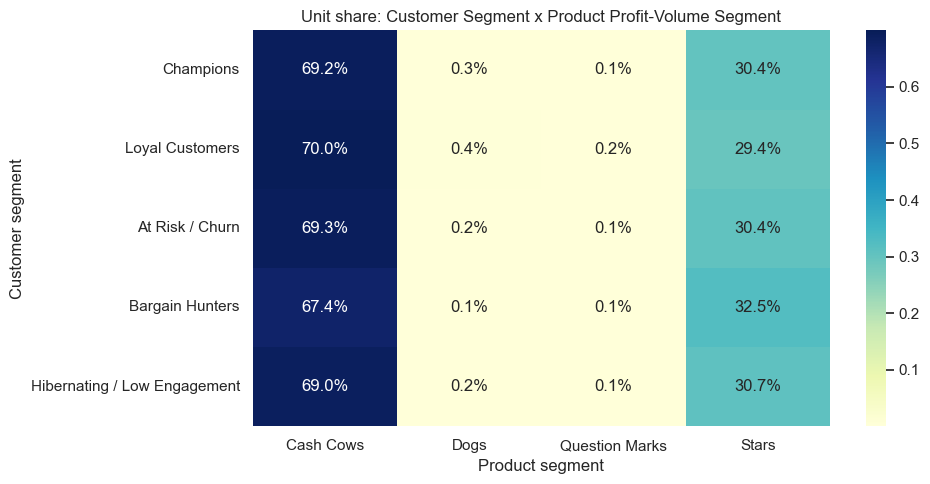

In [ ]:
orders_with_segments = (
    valid_orders[["order_id", "customer_id", "order_date", "order_source", "device_type", "payment_method"]]
    .merge(rfm[["customer_id", "customer_segment"]], on="customer_id", how="left")
)

line_items_enriched = (
    order_items
    .merge(orders_with_segments, on="order_id", how="inner")
    .merge(products[["product_id", "product_name", "category", "segment", "price", "cogs"]], on="product_id", how="left")
    .merge(product_segments[["product_id", "gross_margin", "sales_volume", "product_segment_pv"]], on="product_id", how="left")
    .merge(customers[["customer_id", "age_group", "gender", "acquisition_channel"]], on="customer_id", how="left")
)

line_items_enriched["discount_amount"] = line_items_enriched["discount_amount"].fillna(0)
line_items_enriched["line_gross"] = line_items_enriched["quantity"] * line_items_enriched["unit_price"]
line_items_enriched["line_net"] = line_items_enriched["line_gross"] - line_items_enriched["discount_amount"]
line_items_enriched["discount_rate_line"] = (
    line_items_enriched["discount_amount"] / line_items_enriched["line_gross"].replace(0, np.nan)
).fillna(0)
line_items_enriched["has_promo"] = line_items_enriched[promo_cols].notna().any(axis=1) if promo_cols else False

cross_segment_summary = (
    line_items_enriched.groupby(["customer_segment", "product_segment_pv"])
    .agg(orders=("order_id", "nunique"), units=("quantity", "sum"), revenue=("line_gross", "sum"), discount=("discount_amount", "sum"), promo_line_rate=("has_promo", "mean"))
    .reset_index()
)
cross_segment_summary["segment_units_share"] = cross_segment_summary["units"] / cross_segment_summary.groupby("customer_segment")["units"].transform("sum")

pivot_units_share = cross_segment_summary.pivot_table(
    index="customer_segment", columns="product_segment_pv", values="segment_units_share", fill_value=0
).loc[customer_segment_order]

display(cross_segment_summary.sort_values(["customer_segment", "units"], ascending=[True, False]).style.format({
    "orders": "{:,.0f}", "units": "{:,.0f}", "revenue": "{:,.0f}", "discount": "{:,.0f}",
    "promo_line_rate": "{:.2%}", "segment_units_share": "{:.2%}",
}))

fig, ax = plt.subplots(figsize=(10, 5))
sns.heatmap(pivot_units_share, annot=True, fmt=".1%", cmap="YlGnBu", ax=ax)
ax.set_title("Unit share: Customer Segment x Product Profit-Volume Segment")
ax.set_xlabel("Product segment")
ax.set_ylabel("Customer segment")
plt.tight_layout()
plt.show()

## 3.2. Apriori-style association rules, price sensitivity và channel conversion

**Association rules: Customer Segment → Product Profit-Volume Segment**

,customer_segment,product_segment_pv,support,confidence,lift,rule_orders,antecedent_orders
1,At Risk / Churn,Cash Cows,23.35%,71.65%,1.00,"120,640","168,385"
3,At Risk / Churn,Stars,10.52%,32.28%,1.00,"54,352","168,385"
11,At Risk / Churn,Dogs,0.07%,0.22%,0.82,370,"168,385"
10,At Risk / Churn,Question Marks,0.03%,0.10%,0.82,172,"168,385"
9,Bargain Hunters,Cash Cows,2.72%,70.19%,0.98,"14,074","20,051"
7,Bargain Hunters,Stars,1.35%,34.90%,1.08,"6,998","20,051"
2,Champions,Cash Cows,32.25%,72.02%,1.00,"166,621","231,345"
8,Champions,Stars,14.54%,32.48%,1.00,"75,146","231,345"
13,Champions,Dogs,0.14%,0.31%,1.17,721,"231,345"
14,Champions,Question Marks,0.06%,0.14%,1.16,331,"231,345"


**Association rules: Customer Segment → Category | Product Segment**

,customer_segment,category_segment,support,confidence,lift,rule_orders
6,At Risk / Churn,Streetwear|Everyday,9.52%,29.21%,1.04,"49,189"
3,At Risk / Churn,Outdoor|Activewear,8.08%,24.81%,0.94,"41,770"
1,At Risk / Churn,Streetwear|Balanced,5.22%,16.00%,1.01,"26,949"
20,At Risk / Churn,Streetwear|Performance,5.04%,15.46%,1.04,"26,024"
19,At Risk / Churn,GenZ|Trendy,1.91%,5.85%,1.02,"9,856"
16,Bargain Hunters,Outdoor|Activewear,1.65%,42.45%,1.62,"8,512"
11,Bargain Hunters,Streetwear|Everyday,0.93%,23.90%,0.85,"4,793"
22,Bargain Hunters,Streetwear|Performance,0.34%,8.80%,0.59,"1,764"
28,Bargain Hunters,GenZ|Trendy,0.30%,7.84%,1.37,"1,571"
30,Bargain Hunters,Streetwear|Balanced,0.23%,6.01%,0.38,"1,205"


**Price sensitivity: top discount rate by customer segment**

,customer_segment,product_segment_pv,lines,avg_discount_rate,promo_line_rate,discounted_line_share,revenue
0,At Risk / Churn,Cash Cows,"128,088",5.45%,38.44%,38.44%,"3,106,169,421"
3,At Risk / Churn,Stars,"56,240",5.40%,37.96%,37.96%,"1,216,462,031"
2,At Risk / Churn,Question Marks,175,4.78%,34.29%,34.29%,"4,495,299"
7,Bargain Hunters,Stars,"7,331",6.60%,44.07%,44.07%,"66,155,111"
4,Bargain Hunters,Cash Cows,"15,290",6.57%,44.49%,44.49%,"141,778,648"
5,Bargain Hunters,Dogs,25,5.84%,36.00%,36.00%,"257,992"
10,Champions,Question Marks,337,6.41%,40.36%,40.36%,"8,681,758"
11,Champions,Stars,"78,238",5.57%,38.52%,38.52%,"1,684,105,911"
8,Champions,Cash Cows,"178,198",5.55%,38.70%,38.70%,"4,319,511,007"
15,Hibernating / Low Engagement,Stars,"20,866",5.29%,37.07%,37.07%,"472,681,676"


**Category preference: age_group 18-24 & acquisition_channel social_media**

,category,unit_share
0,Streetwear,55.34%
1,Outdoor,35.78%
2,GenZ,5.44%
3,Casual,3.44%


,customer_segment,category,units,unit_share
3,At Risk / Churn,Streetwear,"13,792",56.90%
2,At Risk / Churn,Outdoor,"8,343",34.42%
1,At Risk / Churn,GenZ,"1,304",5.38%
6,Bargain Hunters,Outdoor,"1,400",60.29%
7,Bargain Hunters,Streetwear,640,27.56%
5,Bargain Hunters,GenZ,201,8.66%
11,Champions,Streetwear,"16,873",55.33%
10,Champions,Outdoor,"10,936",35.86%
9,Champions,GenZ,"1,562",5.12%
15,Hibernating / Low Engagement,Streetwear,"5,241",56.94%


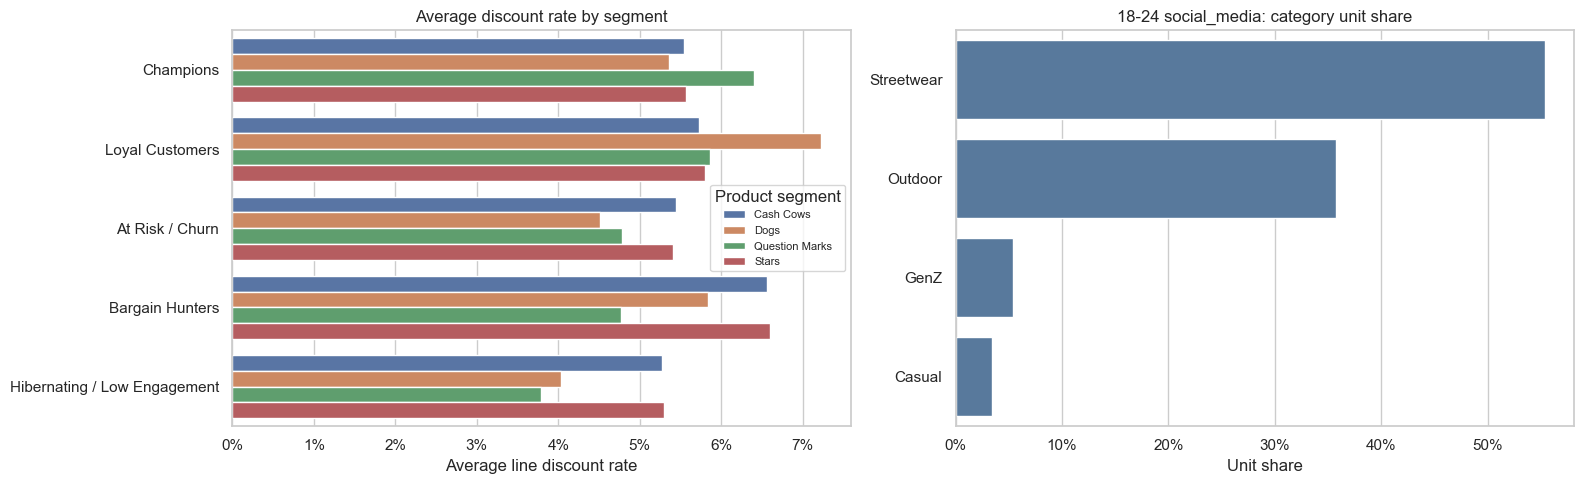

In [ ]:
basket_source = line_items_enriched[["order_id", "customer_segment", "product_segment_pv", "category", "segment"]].dropna(subset=["customer_segment"])
basket_source = basket_source.assign(
    cs_token="CS=" + basket_source["customer_segment"].astype(str),
    pv_token="PV=" + basket_source["product_segment_pv"].astype(str),
    category_token="CATEGORY=" + basket_source["category"].astype(str),
    catseg_token="CATSEG=" + basket_source["category"].astype(str) + "|" + basket_source["segment"].astype(str),
)

order_tokens = (
    basket_source.groupby("order_id")
    .agg(
        customer_token=("cs_token", "first"),
        pv_tokens=("pv_token", lambda s: set(s.dropna())),
        category_tokens=("category_token", lambda s: set(s.dropna())),
        catseg_tokens=("catseg_token", lambda s: set(s.dropna())),
    )
    .reset_index()
)
baskets = [{row.customer_token} | row.pv_tokens | row.category_tokens | row.catseg_tokens for row in order_tokens.itertuples(index=False)]

def apriori_pair_rules(baskets, antecedent_prefix="CS=", consequent_prefixes=("PV=",), min_support=0.001, min_confidence=0.01):
    n_baskets = len(baskets)
    item_counts = Counter()
    pair_counts = Counter()
    for basket in baskets:
        unique_items = set(basket)
        item_counts.update(unique_items)
        antecedents = [item for item in unique_items if item.startswith(antecedent_prefix)]
        consequents = [item for item in unique_items if item.startswith(consequent_prefixes)]
        for antecedent in antecedents:
            for consequent in consequents:
                if antecedent != consequent:
                    pair_counts[(antecedent, consequent)] += 1
    records = []
    for (antecedent, consequent), pair_count in pair_counts.items():
        support = pair_count / n_baskets
        confidence = pair_count / item_counts[antecedent]
        consequent_support = item_counts[consequent] / n_baskets
        lift = confidence / consequent_support if consequent_support else np.nan
        if support >= min_support and confidence >= min_confidence:
            records.append({
                "antecedent": antecedent, "consequent": consequent, "support": support,
                "confidence": confidence, "lift": lift, "rule_orders": pair_count,
                "antecedent_orders": item_counts[antecedent],
            })
    return pd.DataFrame(records).sort_values(["antecedent", "confidence"], ascending=[True, False])

pv_rules = apriori_pair_rules(baskets, consequent_prefixes=("PV=",), min_support=0.0001, min_confidence=0.0001)
pv_rules = pv_rules.assign(
    customer_segment=pv_rules["antecedent"].str.replace("CS=", "", regex=False),
    product_segment_pv=pv_rules["consequent"].str.replace("PV=", "", regex=False),
)

catseg_rules = apriori_pair_rules(baskets, consequent_prefixes=("CATSEG=",), min_support=0.001, min_confidence=0.03)
catseg_rules = catseg_rules.assign(
    customer_segment=catseg_rules["antecedent"].str.replace("CS=", "", regex=False),
    category_segment=catseg_rules["consequent"].str.replace("CATSEG=", "", regex=False),
)

display(Markdown("**Association rules: Customer Segment → Product Profit-Volume Segment**"))
display(pv_rules.sort_values(["customer_segment", "confidence"], ascending=[True, False]).groupby("customer_segment").head(4)[
    ["customer_segment", "product_segment_pv", "support", "confidence", "lift", "rule_orders", "antecedent_orders"]
].style.format({"support": "{:.2%}", "confidence": "{:.2%}", "lift": "{:.2f}", "rule_orders": "{:,.0f}", "antecedent_orders": "{:,.0f}"}))

display(Markdown("**Association rules: Customer Segment → Category | Product Segment**"))
display(catseg_rules.sort_values(["customer_segment", "confidence"], ascending=[True, False]).groupby("customer_segment").head(5)[
    ["customer_segment", "category_segment", "support", "confidence", "lift", "rule_orders"]
].style.format({"support": "{:.2%}", "confidence": "{:.2%}", "lift": "{:.2f}", "rule_orders": "{:,.0f}"}))

price_sensitivity = (
    line_items_enriched.groupby(["customer_segment", "product_segment_pv"])
    .agg(lines=("order_id", "size"), avg_discount_rate=("discount_rate_line", "mean"), promo_line_rate=("has_promo", "mean"), discounted_line_share=("discount_amount", lambda s: (s > 0).mean()), revenue=("line_gross", "sum"))
    .reset_index()
)
display(Markdown("**Price sensitivity: top discount rate by customer segment**"))
display(price_sensitivity.sort_values(["customer_segment", "avg_discount_rate"], ascending=[True, False]).groupby("customer_segment").head(3).style.format({
    "lines": "{:,.0f}", "avg_discount_rate": "{:.2%}", "promo_line_rate": "{:.2%}", "discounted_line_share": "{:.2%}", "revenue": "{:,.0f}",
}))

young_social = line_items_enriched.loc[
    line_items_enriched["age_group"].eq("18-24") & line_items_enriched["acquisition_channel"].eq("social_media")
].copy()
young_social_category_share = (
    young_social.groupby("category")["quantity"].sum().pipe(lambda s: (s / s.sum()).sort_values(ascending=False)).reset_index(name="unit_share")
)
young_social_by_segment = young_social.groupby(["customer_segment", "category"])["quantity"].sum().reset_index(name="units")
young_social_by_segment["unit_share"] = young_social_by_segment["units"] / young_social_by_segment.groupby("customer_segment")["units"].transform("sum")

display(Markdown("**Category preference: age_group 18-24 & acquisition_channel social_media**"))
display(young_social_category_share.style.format({"unit_share": "{:.2%}"}))
display(young_social_by_segment.sort_values(["customer_segment", "unit_share"], ascending=[True, False]).groupby("customer_segment").head(3).style.format({"units": "{:,.0f}", "unit_share": "{:.2%}"}))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=price_sensitivity, x="avg_discount_rate", y="customer_segment", hue="product_segment_pv", order=customer_segment_order, ax=axes[0])
axes[0].set_title("Average discount rate by segment")
axes[0].set_xlabel("Average line discount rate")
axes[0].set_ylabel("")
axes[0].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
axes[0].legend(title="Product segment", fontsize=8)

sns.barplot(data=young_social_category_share, x="unit_share", y="category", ax=axes[1], color="#4C78A8")
axes[1].set_title("18-24 social_media: category unit share")
axes[1].set_xlabel("Unit share")
axes[1].set_ylabel("")
axes[1].xaxis.set_major_formatter(lambda x, pos: f"{x:.0%}")
plt.tight_layout()
plt.show()

**Nhận xét:**

- **Quan sát:**
  - **Customer Segment → Product Segment:** Tất cả nhóm khách đều mua **Cash Cows** nhiều nhất, confidence khoảng **70-72%**, kế đến là **Stars** khoảng **31-35%**.
  - **Champions:** Có confidence gần cân bằng giữa `Streetwear|Everyday` và `Outdoor|Activewear`, đều khoảng **26.8%**; phù hợp để cross-sell từ sản phẩm volume cao sang sản phẩm Stars có margin cao.
  - **Bargain Hunters:** Có affinity nổi bật với `Outdoor|Activewear` với confidence khoảng **42.5%**; đồng thời promo/discount rate cao nhất trên Cash Cows và Stars, khoảng **44% line có promo** và discount rate khoảng **6.6%**.
  - **Kênh social_media nhóm 18-24:** Tổng thể mua **Streetwear ~55.3% units** và **Outdoor ~35.8% units**. Tuy nhiên riêng Bargain Hunters trong lát cắt này lại nghiêng mạnh về Outdoor, khoảng **60.3% units**.

- **Insights:**
  - **Không phải mọi segment đều cần cùng một product mix:** Champions và Loyal phù hợp với Streetwear/Outdoor cân bằng, trong khi Bargain Hunters phản ứng mạnh hơn với Outdoor Activewear và khuyến mãi.
  - **Stars nên được dùng làm sản phẩm nâng cấp:** Vì Stars có margin cao nhưng confidence thấp hơn Cash Cows, chiến lược tốt là bundle/recommendation đi kèm Cash Cows.
  - **Bargain Hunters có rủi ro làm loãng lợi nhuận:** Họ có mức nhạy khuyến mãi cao nhất nhưng giá trị vòng đời thấp nhất; voucher không điều kiện dễ ăn margin mà không tạo loyalty.
  - **Giả thuyết “18-24 social_media thích Streetwear” đúng ở tổng thể nhưng không đồng nhất:** Khi tách theo segment, Bargain Hunters trẻ đến từ social_media lại ưu tiên Outdoor.

- **Gợi ý hành động:**
  - **Champions:** Đẩy combo `Streetwear|Everyday` + Stars hoặc `Outdoor|Activewear` + phụ kiện margin cao; ưu tiên recommendation cá nhân hoá thay vì giảm giá mạnh.
  - **At Risk / Churn:** Dùng win-back gắn với category từng có confidence cao như `Streetwear|Everyday` và `Outdoor|Activewear`.
  - **Bargain Hunters:** Chạy promo có điều kiện trên Cash Cows/Outdoor Activewear, ví dụ minimum order value, bundle xả tồn, hoặc voucher chỉ dùng khi mua kèm Stars.
  - **18-24 social_media:** Tách campaign thành 2 nhánh: Streetwear creative cho Champions/Loyal/At Risk, Outdoor deal-led creative cho Bargain Hunters.

In [11]:
# 4. Lưu bảng kết quả để dùng tiếp trong modeling/dashboard
customer_segments.to_csv(OUTPUT_DIR / "customer_rfm_segments.csv", index=False)
product_segments.to_csv(OUTPUT_DIR / "product_profit_volume_segments.csv", index=False)
cross_segment_summary.to_csv(OUTPUT_DIR / "customer_product_cross_mapping.csv", index=False)
pv_rules.to_csv(OUTPUT_DIR / "association_rules_customer_to_product_segment.csv", index=False)
catseg_rules.to_csv(OUTPUT_DIR / "association_rules_customer_to_category_segment.csv", index=False)

print("Saved outputs:")
for filename in [
    "customer_rfm_segments.csv",
    "product_profit_volume_segments.csv",
    "customer_product_cross_mapping.csv",
    "association_rules_customer_to_product_segment.csv",
    "association_rules_customer_to_category_segment.csv",
]:
    print("-", OUTPUT_DIR / filename)

Saved outputs:
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\customer_rfm_segments.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\product_profit_volume_segments.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\customer_product_cross_mapping.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\association_rules_customer_to_product_segment.csv
- d:\University\Competitions\Datathon VinUni\DATATHON-2026-VinUni\outputs\association_rules_customer_to_category_segment.csv


# 5. Phân tích theo từng segment

Revenue được biểu diễn theo công thức:

$$
Revenue = unit\_price \times quantity
$$

Mỗi target đều đi theo trình tự: kiểm định giả thuyết, preprocessing, feature engineering/feature selection bằng Mutual Information, RFE, SHAP, modeling regression/tree-based, giải thích model, và mô phỏng counterfactual để rút ra quyết định tối ưu cho từng segment.

## 5.1. Chuẩn bị bảng modeling profit theo segment

In [17]:
returns = pd.read_csv(DATA_DIR / "returns.csv", parse_dates=["return_date"])
shipments = pd.read_csv(DATA_DIR / "shipments.csv", parse_dates=["ship_date", "delivery_date"])
web_traffic = pd.read_csv(DATA_DIR / "web_traffic.csv", parse_dates=["date"])

segment_lookup = rfm[["customer_id", "customer_segment"]].drop_duplicates()

model_base = (
    order_items.copy()
    .merge(
        orders[["order_id", "order_date", "customer_id", "order_status", "order_source", "device_type", "payment_method"]],
        on="order_id",
        how="left",
    )
    .merge(segment_lookup, on="customer_id", how="left")
    .merge(customers[["customer_id", "age_group"]], on="customer_id", how="left")
    .merge(products[["product_id", "price", "cogs", "category", "segment"]], on="product_id", how="left")
)
model_base = model_base.dropna(subset=["customer_segment"]).copy()

# Promotions: giữ cả promo_id và promo_id_2, đồng thời lấy metadata của promotion.
promo_ref = promotions[[
    "promo_id", "promo_type", "discount_value", "stackable_flag", "applicable_category", "min_order_value"
]].copy()
promo_ref["promo_id_key"] = promo_ref["promo_id"].astype("string")

for source_col, prefix in [("promo_id", "primary"), ("promo_id_2", "secondary")]:
    model_base[source_col] = model_base[source_col].astype("string")
    promo_tmp = promo_ref.rename(columns={
        "promo_id": f"promo_id_{prefix}_ref",
        "promo_type": f"promo_type_{prefix}",
        "discount_value": f"discount_value_{prefix}",
        "stackable_flag": f"stackable_flag_{prefix}",
        "applicable_category": f"applicable_category_{prefix}",
        "min_order_value": f"min_order_value_{prefix}",
    })
    model_base = model_base.merge(
        promo_tmp,
        left_on=source_col,
        right_on="promo_id_key",
        how="left",
    ).drop(columns=["promo_id_key", f"promo_id_{prefix}_ref"])

discount_cols = ["discount_value_primary", "discount_value_secondary"]
min_order_cols = ["min_order_value_primary", "min_order_value_secondary"]
stackable_cols = ["stackable_flag_primary", "stackable_flag_secondary"]
model_base["has_promo"] = model_base[["promo_id", "promo_id_2"]].notna().any(axis=1).astype(int)
model_base["discount_value_max"] = model_base[discount_cols].max(axis=1).fillna(0)
model_base["min_order_value_max"] = model_base[min_order_cols].max(axis=1).fillna(0)
model_base["stackable_any"] = model_base[stackable_cols].max(axis=1).fillna(0)

# Inventory join theo product_id + tháng của order.
model_base["year"] = model_base["order_date"].dt.year
model_base["month"] = model_base["order_date"].dt.month
model_base["order_dayofweek"] = model_base["order_date"].dt.dayofweek
inventory_month = (
    inventory.groupby(["product_id", "year", "month"], as_index=False)
    .agg(
        stock_on_hand=("stock_on_hand", "mean"),
        stockout_flag=("stockout_flag", "max"),
        stockout_days=("stockout_days", "mean"),
        units_received=("units_received", "sum"),
        units_sold=("units_sold", "sum"),
        overstock_flag=("overstock_flag", "max"),
    )
)
model_base = model_base.merge(inventory_month, on=["product_id", "year", "month"], how="left")

# Web traffic join theo ngày order và nguồn traffic/order_source.
web_daily = (
    web_traffic.groupby(["date", "traffic_source"], as_index=False)
    .agg(
        sessions=("sessions", "sum"),
        unique_visitors=("unique_visitors", "sum"),
        page_views=("page_views", "sum"),
        bounce_rate=("bounce_rate", "mean"),
        avg_session_duration_sec=("avg_session_duration_sec", "mean"),
    )
)
model_base["order_date_only"] = model_base["order_date"].dt.normalize()
model_base = model_base.merge(
    web_daily,
    left_on=["order_date_only", "order_source"],
    right_on=["date", "traffic_source"],
    how="left",
).drop(columns=["date"])

# Returns và shipments cho cost model.
returns_agg = (
    returns.groupby(["order_id", "product_id"], as_index=False)
    .agg(return_quantity=("return_quantity", "sum"), refund_amount=("refund_amount", "sum"))
)
shipments_agg = shipments.groupby("order_id", as_index=False).agg(shipping_fee=("shipping_fee", "sum"))
model_base = model_base.merge(returns_agg, on=["order_id", "product_id"], how="left")
model_base = model_base.merge(shipments_agg, on="order_id", how="left")
model_base[["return_quantity", "refund_amount", "shipping_fee"]] = model_base[[
    "return_quantity", "refund_amount", "shipping_fee"
]].fillna(0)

model_base["revenue"] = model_base["unit_price"] * model_base["quantity"]
order_gross = model_base.groupby("order_id")["revenue"].transform("sum").replace(0, np.nan)
model_base["shipping_fee_allocated"] = (model_base["shipping_fee"] * model_base["revenue"] / order_gross).fillna(0)
model_base["product_cogs_cost"] = model_base["cogs"] * model_base["quantity"]
model_base["return_cogs_cost"] = model_base["cogs"] * model_base["return_quantity"]
model_base["cost"] = model_base["product_cogs_cost"] + model_base["shipping_fee_allocated"] + model_base["return_cogs_cost"]

modeling_overview = (
    model_base.groupby("customer_segment")
    .agg(
        rows=("order_id", "size"),
        orders=("order_id", "nunique"),
        revenue=("revenue", "sum"),
        cost=("cost", "sum"),
        avg_unit_price=("unit_price", "mean"),
        avg_quantity=("quantity", "mean"),
    )
    .reset_index()
)
modeling_overview["profit_proxy"] = modeling_overview["revenue"] - modeling_overview["cost"]
display(modeling_overview.style.format({
    "rows": "{:,.0f}",
    "orders": "{:,.0f}",
    "revenue": "{:,.0f}",
    "cost": "{:,.0f}",
    "avg_unit_price": "{:,.2f}",
    "avg_quantity": "{:,.2f}",
    "profit_proxy": "{:,.0f}",
}))

,customer_segment,rows,orders,revenue,cost,avg_unit_price,avg_quantity,profit_proxy
0,At Risk / Churn,"229,515","209,117","5,384,552,440","4,789,192,388","5,176.56",4.52,"595,360,053"
1,Bargain Hunters,"28,425","25,298","332,697,054","308,067,366","3,455.88",3.84,"24,629,688"
2,Champions,"317,665","285,269","7,414,879,860","6,586,038,405","5,168.52",4.51,"828,841,455"
3,Hibernating / Low Engagement,"85,238","77,844","2,050,118,555","1,818,581,474","5,216.86",4.61,"231,537,080"
4,Loyal Customers,"47,420","43,597","1,103,035,845","993,387,634","5,276.29",4.45,"109,648,212"


**Nhận xét:**

**Quan sát**

- **Cơ cấu doanh thu và khách hàng**

    - Champions là nhóm khách hàng quan trọng nhất, chiếm tỷ trọng cao nhất cả về số lượng (hơn 317k rows) và doanh thu (7.4 tỷ). Hiệu quả kinh doanh phụ thuộc rất lớn vào việc duy trì nhóm này.

    - At Risk / Churn: Nhóm có nguy cơ rời bỏ đang chiếm số lượng cực lớn (229,515 khách hàng). Doanh thu từ nhóm này đạt hơn 5.3 tỷ. Nếu không có chiến dịch cứu vãn kịp thời, doanh nghiệp sẽ mất đi một nguồn thu khổng lồ.

- **Phân tích giá trị đơn hàng (Average Unit Price & Quantity)**

    - Bargain Hunters: Nhóm Săn sale có mức giá trung bình đơn vị thấp nhất (3,455) và số lượng mua mỗi lần cũng thấp nhất (3.84). Điều này cho thấy họ chỉ tập trung vào các sản phẩm giá rẻ hoặc có khuyến mãi sâu.

    - Nhóm Loyal Customers và Hibernating đang trả mức giá trung bình cao nhất (trên 5,200). Điều này gợi ý rằng khách hàng trung thành không phải vì giá rẻ mà vì giá trị thương hiệu hoặc chất lượng sản phẩm.

- **Hiệu quả lợi nhuận (Profit Proxy)**

    - Tỷ suất lợi nhuận/doanh thu nhìn chung khá đồng đều giữa các nhóm (dao động quanh mức 11-12%).

    - Tuy nhiên, nhóm Hibernating (Ngủ đông) đang giữ mức giá trung bình cao và số lượng mua trung bình cao nhất (4.61). Đây là nhóm "tiềm năng bị bỏ quên" – họ từng sẵn sàng chi đậm nhưng hiện đang thiếu sự tương tác.


**Đề xuất hành động**

- Đối với Champions: Triển khai chương trình tri ân đặc quyền để giữ chân và biến họ thành đại sứ thương hiệu.

- Đối với At Risk / Churn: Cần thực hiện khảo sát hoặc gửi các mã giảm giá "nhớ bạn" ngay lập tức để tìm hiểu lý do họ rời đi và kéo họ quay lại.

- Đối với Hibernating: Sử dụng các chiến dịch Marketing Automation (Email/SMS) nhắc nhớ về sản phẩm mới dựa trên lịch sử mua hàng có giá trị cao trước đó của họ.

- Đối với Bargain Hunters: Chỉ nên tiếp cận khi có các chương trình xả kho hoặc chiến dịch đẩy doanh số cuối mùa, tránh lãng phí chi phí marketing cao cấp vào nhóm này.



## 5.2. Hàm kiểm định giả thuyết, modeling pipeline, SHAP/feature importance và counterfactual

In [ ]:
from scipy import stats
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold, mutual_info_regression, RFE
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.stattools import jarque_bera
import shap

try:
    from xgboost import XGBRegressor
except Exception:
    XGBRegressor = None
try:
    from lightgbm import LGBMRegressor
except Exception:
    LGBMRegressor = None
try:
    from catboost import CatBoostRegressor
except Exception:
    CatBoostRegressor = None

try:
    _ = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    def make_ohe():
        return OneHotEncoder(handle_unknown="ignore", sparse=False)

MAX_ROWS_PER_MODEL = 300
TOP_K_FEATURES = 8
CV_SPLITS = 2
MIN_ROWS_PER_MODEL = 120

In [ ]:
def regression_metric_dict(y_true_log, y_pred_log):
    y_true = np.expm1(y_true_log)
    y_pred = np.maximum(0, np.expm1(y_pred_log))
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "R2": r2_score(y_true, y_pred),
    }

def test_numeric_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30 or tmp[feature].nunique() < 2:
        return None
    stat, p_value = stats.spearmanr(tmp[feature], tmp[target])
    return {
        "feature": feature,
        "test": "Spearman correlation",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"rho={stat:.3f}",
    }

def test_binary_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30 or tmp[feature].nunique() != 2:
        return None
    values = sorted(tmp[feature].unique())
    g0 = tmp.loc[tmp[feature].eq(values[0]), target]
    g1 = tmp.loc[tmp[feature].eq(values[1]), target]
    if len(g0) < 10 or len(g1) < 10:
        return None
    stat, p_value = stats.mannwhitneyu(g0, g1, alternative="two-sided")
    median_diff = g1.median() - g0.median()
    return {
        "feature": feature,
        "test": "Mann-Whitney U",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"median_diff({values[1]}-{values[0]})={median_diff:,.3f}",
    }

def test_categorical_relation(df, feature, target):
    tmp = df[[feature, target]].replace([np.inf, -np.inf], np.nan).dropna()
    if len(tmp) < 30:
        return None
    counts = tmp[feature].value_counts()
    valid_levels = counts[counts >= 10].index
    tmp = tmp[tmp[feature].isin(valid_levels)]
    if tmp[feature].nunique() < 2 or tmp[feature].nunique() > 30:
        return None
    groups = [g[target].values for _, g in tmp.groupby(feature)]
    stat, p_value = stats.kruskal(*groups)
    return {
        "feature": feature,
        "test": "Kruskal-Wallis",
        "statistic": stat,
        "p_value": p_value,
        "n": len(tmp),
        "effect_note": f"groups={tmp[feature].nunique()}",
    }

def run_hypothesis_tests(df, target, config):
    records = []
    for feature, feature_type in config["hypothesis_features"]:
        if feature not in df.columns:
            continue
        if feature_type == "numeric":
            out = test_numeric_relation(df, feature, target)
        elif feature_type == "binary":
            out = test_binary_relation(df, feature, target)
        else:
            out = test_categorical_relation(df, feature, target)
        if out is not None:
            records.append(out)
    return pd.DataFrame(records)

def build_preprocessor(X):
    numeric_cols = X.select_dtypes(include=["number", "bool"]).columns.tolist()
    categorical_cols = [col for col in X.columns if col not in numeric_cols]
    preprocessor = ColumnTransformer(
        transformers=[
            ("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), numeric_cols),
            ("cat", Pipeline([("imputer", SimpleImputer(strategy="most_frequent")), ("ohe", make_ohe())]), categorical_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=True,
    )
    return preprocessor, numeric_cols, categorical_cols

def preprocess_and_select_features(X_train, X_test, y_train_log):
    X_train = X_train.copy().replace({pd.NA: np.nan})
    X_test = X_test.copy().replace({pd.NA: np.nan})
    for _col in X_train.select_dtypes(include=["object", "string", "category"]).columns:
        X_train[_col] = X_train[_col].astype(object)
        X_test[_col] = X_test[_col].astype(object)
        X_train[_col] = X_train[_col].where(X_train[_col].notna(), "__missing__")
        X_test[_col] = X_test[_col].where(X_test[_col].notna(), "__missing__")
    preprocessor, numeric_cols, categorical_cols = build_preprocessor(X_train)
    X_train_arr = preprocessor.fit_transform(X_train)
    X_test_arr = preprocessor.transform(X_test)
    feature_names = preprocessor.get_feature_names_out()
    X_train_fe = pd.DataFrame(X_train_arr, columns=feature_names, index=X_train.index)
    X_test_fe = pd.DataFrame(X_test_arr, columns=feature_names, index=X_test.index)

    vt = VarianceThreshold(threshold=0.0)
    X_train_vt_arr = vt.fit_transform(X_train_fe)
    X_test_vt_arr = vt.transform(X_test_fe)
    kept_features = X_train_fe.columns[vt.get_support()].tolist()
    dropped_features = X_train_fe.columns[~vt.get_support()].tolist()
    X_train_vt = pd.DataFrame(X_train_vt_arr, columns=kept_features, index=X_train.index)
    X_test_vt = pd.DataFrame(X_test_vt_arr, columns=kept_features, index=X_test.index)

    mi_scores = mutual_info_regression(X_train_vt, y_train_log, random_state=RANDOM_STATE)
    mi_series = pd.Series(mi_scores, index=X_train_vt.columns).sort_values(ascending=False)

    k_features = min(TOP_K_FEATURES, X_train_vt.shape[1])
    if X_train_vt.shape[1] <= k_features:
        rfe_features = X_train_vt.columns.tolist()
        rfe_rank = pd.DataFrame({"feature": X_train_vt.columns, "rank": 1})
    else:
        rfe_estimator = RandomForestRegressor(
            n_estimators=8, max_depth=4, random_state=RANDOM_STATE, n_jobs=1
        )
        rfe = RFE(estimator=rfe_estimator, n_features_to_select=k_features, step=0.25)
        rfe.fit(X_train_vt, y_train_log)
        rfe_features = X_train_vt.columns[rfe.support_].tolist()
        rfe_rank = pd.DataFrame({"feature": X_train_vt.columns, "rank": rfe.ranking_}).sort_values("rank")

    shap_status = "SHAP"
    try:
        shap_model = RandomForestRegressor(
            n_estimators=10, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
        )
        shap_model.fit(X_train_vt, y_train_log)
        shap_sample = X_train_vt.sample(min(50, len(X_train_vt)), random_state=RANDOM_STATE)
        shap_values = shap.TreeExplainer(shap_model).shap_values(shap_sample)
        shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train_vt.columns).sort_values(ascending=False)
    except Exception as exc:
        shap_status = f"feature_importances fallback ({exc.__class__.__name__})"
        shap_model = RandomForestRegressor(
            n_estimators=10, max_depth=5, random_state=RANDOM_STATE, n_jobs=1
        )
        shap_model.fit(X_train_vt, y_train_log)
        shap_importance = pd.Series(shap_model.feature_importances_, index=X_train_vt.columns).sort_values(ascending=False)

    selected_features = []
    for feature in list(mi_series.head(TOP_K_FEATURES).index) + rfe_features + list(shap_importance.head(TOP_K_FEATURES).index):
        if feature not in selected_features:
            selected_features.append(feature)
    selected_features = selected_features[: max(TOP_K_FEATURES, min(20, len(selected_features)))]

    return {
        "preprocessor": preprocessor,
        "numeric_cols": numeric_cols,
        "categorical_cols": categorical_cols,
        "kept_features": kept_features,
        "dropped_features": dropped_features,
        "X_train_vt": X_train_vt,
        "X_test_vt": X_test_vt,
        "X_train_final": X_train_vt[selected_features],
        "X_test_final": X_test_vt[selected_features],
        "selected_features": selected_features,
        "mi_series": mi_series,
        "rfe_rank": rfe_rank,
        "shap_importance": shap_importance,
        "shap_status": shap_status,
    }

def make_model_specs():
    specs = {
        "Linear Regression": (LinearRegression(), {}),
        "Ridge": (Ridge(random_state=RANDOM_STATE), {"alpha": [0.1, 1.0, 10.0]}),
        "Lasso": (Lasso(random_state=RANDOM_STATE, max_iter=5000), {"alpha": [0.0005, 0.001, 0.01]}),
        "Random Forest": (
            RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
            {"n_estimators": [12], "max_depth": [4], "min_samples_leaf": [2]},
        ),
    }
    if XGBRegressor is not None:
        specs["XGBoost"] = (
            XGBRegressor(
                objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=1,
                tree_method="hist", verbosity=0
            ),
            {"n_estimators": [12], "max_depth": [3], "learning_rate": [0.05]},
        )
    if LGBMRegressor is not None:
        specs["LightGBM"] = (
            LGBMRegressor(objective="regression", random_state=RANDOM_STATE, n_jobs=1, verbose=-1),
            {"n_estimators": [12], "max_depth": [4], "learning_rate": [0.05]},
        )
    if CatBoostRegressor is not None:
        specs["CatBoost"] = (
            CatBoostRegressor(
                loss_function="RMSE", random_seed=RANDOM_STATE, verbose=False,
                allow_writing_files=False, thread_count=1
            ),
            {"iterations": [12], "depth": [4], "learning_rate": [0.05]},
        )
    return specs

def fit_and_compare_models(X_train_final, X_test_final, y_train_log, y_test_log):
    cv = KFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    rows = []
    fitted_models = {}

    for name, (estimator, grid) in make_model_specs().items():
        try:
            if grid:
                search = GridSearchCV(
                    estimator,
                    grid,
                    scoring="neg_root_mean_squared_error",
                    cv=cv,
                    n_jobs=1,
                    error_score=np.nan,
                )
                search.fit(X_train_final, y_train_log)
                model = search.best_estimator_
                cv_rmse_log = -search.best_score_
                best_params = search.best_params_
            else:
                model = estimator.fit(X_train_final, y_train_log)
                cv_scores = []
                for train_idx, valid_idx in cv.split(X_train_final):
                    fold_model = LinearRegression()
                    fold_model.fit(X_train_final.iloc[train_idx], y_train_log.iloc[train_idx])
                    pred = fold_model.predict(X_train_final.iloc[valid_idx])
                    cv_scores.append(np.sqrt(mean_squared_error(y_train_log.iloc[valid_idx], pred)))
                cv_rmse_log = float(np.mean(cv_scores))
                best_params = {}

            y_pred_log = model.predict(X_test_final)
            metrics = regression_metric_dict(y_test_log, y_pred_log)
            rows.append({
                "model": name,
                "cv_rmse_log": cv_rmse_log,
                "MAE": metrics["MAE"],
                "RMSE": metrics["RMSE"],
                "R2": metrics["R2"],
                "best_params": best_params,
            })
            fitted_models[name] = model
        except Exception as exc:
            rows.append({
                "model": name,
                "cv_rmse_log": np.nan,
                "MAE": np.nan,
                "RMSE": np.nan,
                "R2": np.nan,
                "best_params": {"error": f"{exc.__class__.__name__}: {exc}"},
            })

    result_df = pd.DataFrame(rows).sort_values(["R2", "RMSE"], ascending=[False, True])
    best_model_name = result_df.dropna(subset=["R2"]).iloc[0]["model"]
    return result_df, fitted_models[best_model_name], best_model_name

def fit_ols_diagnostic(X_train_final, X_test_final, y_train_log, y_test_log):
    try:
        X_train_sm = sm.add_constant(X_train_final, has_constant="add")
        X_test_sm = sm.add_constant(X_test_final, has_constant="add")
        ols = sm.OLS(y_train_log, X_train_sm).fit()
        pred_test = ols.predict(X_test_sm)
        metrics = regression_metric_dict(y_test_log, pred_test)
        jb_stat, jb_p, skew, kurtosis = jarque_bera(ols.resid)
        return {
            "ols_r2_train_log": ols.rsquared,
            "ols_test_r2": metrics["R2"],
            "ols_test_rmse": metrics["RMSE"],
            "condition_number": ols.condition_number,
            "jb_p_value": jb_p,
        }
    except Exception as exc:
        return {"ols_error": f"{exc.__class__.__name__}: {exc}"}

def predict_from_raw(raw_X, feature_pack, selected_model):
    raw_X = raw_X.copy().replace({pd.NA: np.nan})
    for _col in feature_pack.get("categorical_cols", []):
        if _col in raw_X.columns:
            raw_X[_col] = raw_X[_col].astype(object)
            raw_X[_col] = raw_X[_col].where(raw_X[_col].notna(), "__missing__")
    arr = feature_pack["preprocessor"].transform(raw_X)
    feature_names = feature_pack["preprocessor"].get_feature_names_out()
    transformed = pd.DataFrame(arr, columns=feature_names, index=raw_X.index)
    transformed = transformed.reindex(columns=feature_pack["kept_features"], fill_value=0)
    transformed = transformed[feature_pack["selected_features"]]
    return np.maximum(0, np.expm1(selected_model.predict(transformed)))

def run_counterfactuals(raw_X_test, baseline_pred, feature_pack, selected_model, actions):
    records = []
    baseline_mean = float(np.mean(baseline_pred))
    if baseline_mean <= 0:
        return pd.DataFrame(records)

    for action in actions:
        feature = action["feature"]
        if feature not in raw_X_test.columns:
            continue
        modified = raw_X_test.copy()
        if action["type"] == "pct":
            modified[feature] = modified[feature].fillna(modified[feature].median())
            modified[feature] = modified[feature] * (1 + action["value"])
        elif action["type"] == "set":
            modified[feature] = action["value"]
        elif action["type"] == "clip_pct":
            modified[feature] = modified[feature].fillna(modified[feature].median())
            modified[feature] = (modified[feature] * (1 + action["value"])).clip(lower=action.get("lower", 0), upper=action.get("upper", np.inf))
        pred = predict_from_raw(modified, feature_pack, selected_model)
        new_mean = float(np.mean(pred))
        records.append({
            "action": action["label"],
            "feature": feature,
            "baseline_pred_mean": baseline_mean,
            "counterfactual_pred_mean": new_mean,
            "pred_change_pct": (new_mean / baseline_mean - 1) * 100,
            "business_direction": action.get("direction", "increase"),
        })
    return pd.DataFrame(records).sort_values("pred_change_pct", ascending=False)

def render_hypothesis_markdown(segment_name, target_label, config, tests_df):
    text = [
        f"#### Giả thuyết: Các biến trong bảng liên kết có ảnh hưởng đến `{target_label}` của segment **{segment_name}**",
        "",
        "**Biến sử dụng:**",
    ]
    for feature, feature_type in config["hypothesis_features"]:
        text.append(f"- `{feature}`: biến {feature_type}")
    text += [
        "",
        "**Kiểm định thống kê:**",
        "",
        "- Giả thuyết ($H_0$): Feature không tạo khác biệt/correlation có ý nghĩa thống kê với target.",
        "- Giả thuyết ($H_1$): Feature có tạo khác biệt/correlation có ý nghĩa thống kê với target.",
    ]
    display(Markdown("\n".join(text)))
    if len(tests_df):
        display(tests_df.style.format({"statistic": "{:,.4f}", "p_value": "{:.4g}", "n": "{:,.0f}"}))
    else:
        display(Markdown("_Không đủ nhóm/dữ liệu để chạy kiểm định ổn định cho target này._"))

def insight_markdown(segment_name, target_label, config, sample_rows, missing_rate, tests_df, feature_pack, model_results, best_model_name, ols_diag, cf_df):
    significant = tests_df.loc[tests_df["p_value"] < 0.05, "feature"].tolist() if len(tests_df) else []
    top_mi = feature_pack["mi_series"].head(5).index.tolist()
    top_shap = feature_pack["shap_importance"].head(5).index.tolist()
    best_row = model_results.iloc[0]
    linear_row = model_results.loc[model_results["model"].eq("Linear Regression")]
    linear_r2 = linear_row["R2"].iloc[0] if len(linear_row) else np.nan
    top_action = "Chưa có action counterfactual đủ điều kiện."
    if len(cf_df):
        if config["objective"] == "minimize":
            action_df = cf_df.sort_values("pred_change_pct", ascending=True)
        else:
            action_df = cf_df.sort_values("pred_change_pct", ascending=False)
        action = action_df.iloc[0]
        top_action = f"{action['action']} → thay đổi dự đoán trung bình khoảng {action['pred_change_pct']:.2f}%"

    text = f'''
**Nhận xét:**

- **Quan sát:**
  - **Dữ liệu model:** Segment **{segment_name}** với target `{target_label}` dùng {sample_rows:,.0f} dòng sau khi cleaning/sampling; tỷ lệ missing trung bình của các feature là {missing_rate:.2%}.
  - **Kiểm định giả thuyết:** Các biến có p-value < 0.05 gồm: {', '.join(significant[:6]) if significant else 'chưa có biến nổi bật theo kiểm định hiện tại'}.
  - **Feature engineering:** Variance Threshold loại {len(feature_pack['dropped_features']):,.0f} feature hằng số; top Mutual Information gồm {', '.join(top_mi)}.
  - **SHAP/Feature importance:** Top feature theo {feature_pack['shap_status']} gồm {', '.join(top_shap)}.
  - **Modeling:** Best model là **{best_model_name}** với R² test = {best_row['R2']:.3f}, RMSE = {best_row['RMSE']:,.2f}. Linear Regression có R² test = {linear_r2:.3f}. OLS diagnostic: {ols_diag}.

- **Insights:**
  - **Quan hệ phi tuyến:** Nếu best model là tree-based và vượt Linear Regression, quan hệ giữa feature và `{target_label}` không nên được đọc bằng hệ số tuyến tính đơn thuần.
  - **Feature trọng yếu:** Nhóm feature xuất hiện đồng thời trong MI/SHAP nên được ưu tiên khi ra quyết định cho segment này.
  - **Kiểm định vs model:** Kiểm định thống kê giúp xác nhận quan hệ đơn biến; model đa biến cho biết feature nào còn quan trọng sau khi kiểm soát các biến còn lại.

- **Gợi ý hành động:**
  - **Counterfactual thực tế:** {top_action}.
  - **Quyết định:** Ưu tiên action trên nếu phù hợp tồn kho, biên lợi nhuận và chính sách promotion của segment **{segment_name}**.
  - **Theo dõi:** Sau khi triển khai, đo lại `{target_label}` bằng A/B test hoặc holdout để tránh nhầm lẫn giữa correlation và tác động nhân quả thật.
'''
    display(Markdown(text))

def run_segment_target_pipeline(segment_name, config):
    target = config["target"]
    features = [feature for feature in config["features"] if feature in model_base.columns]
    df = model_base.loc[model_base["customer_segment"].eq(segment_name), features + [target]].copy()
    df = df.replace([np.inf, -np.inf], np.nan).dropna(subset=[target])
    df = df.loc[df[target] >= 0].copy()
    if len(df) < MIN_ROWS_PER_MODEL:
        display(Markdown(f"_Segment {segment_name}, target {target}: không đủ dữ liệu để chạy model._"))
        return None

    if len(df) > MAX_ROWS_PER_MODEL:
        df = df.sample(MAX_ROWS_PER_MODEL, random_state=RANDOM_STATE)

    missing_rate = df[features].isna().mean().mean()
    tests_df = run_hypothesis_tests(df, target, config)
    render_hypothesis_markdown(segment_name, target, config, tests_df)

    X = df[features].copy()
    y_log = np.log1p(df[target].astype(float))
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=RANDOM_STATE
    )

    feature_pack = preprocess_and_select_features(X_train, X_test, y_train_log)
    model_results, best_model, best_model_name = fit_and_compare_models(
        feature_pack["X_train_final"], feature_pack["X_test_final"], y_train_log, y_test_log
    )
    ols_diag = fit_ols_diagnostic(
        feature_pack["X_train_final"], feature_pack["X_test_final"], y_train_log, y_test_log
    )

    baseline_pred = predict_from_raw(X_test, feature_pack, best_model)
    cf_df = run_counterfactuals(X_test, baseline_pred, feature_pack, best_model, config["counterfactual_actions"])

    display(Markdown("**2.1 Data preprocessing & 2.2 Feature engineering / selection**"))
    feature_summary = pd.DataFrame({
        "method": ["Mutual Information", "RFE", feature_pack["shap_status"]],
        "top_features": [
            ", ".join(feature_pack["mi_series"].head(8).index),
            ", ".join(feature_pack["rfe_rank"].head(8)["feature"]),
            ", ".join(feature_pack["shap_importance"].head(8).index),
        ],
    })
    display(feature_summary)

    display(Markdown("**2.3 Regression, 2.4 Tree-based models & tuning**"))
    display(model_results.style.format({
        "cv_rmse_log": "{:.4f}", "MAE": "{:,.2f}", "RMSE": "{:,.2f}", "R2": "{:.4f}"
    }))

    display(Markdown("**2.5 SHAP/Feature importance và 3. Counterfactual**"))
    display(feature_pack["shap_importance"].head(10).rename("importance").reset_index().rename(columns={"index": "feature"}).style.format({"importance": "{:,.5f}"}))
    if len(cf_df):
        display(cf_df.style.format({
            "baseline_pred_mean": "{:,.2f}",
            "counterfactual_pred_mean": "{:,.2f}",
            "pred_change_pct": "{:.2f}%",
        }))
    else:
        display(Markdown("_Không có counterfactual hợp lệ cho target này._"))

    insight_markdown(
        segment_name, target, config, len(df), missing_rate, tests_df,
        feature_pack, model_results, best_model_name, ols_diag, cf_df
    )

    return {
        "segment": segment_name,
        "target": target,
        "rows": len(df),
        "missing_rate": missing_rate,
        "best_model": best_model_name,
        "best_r2": model_results.iloc[0]["R2"],
        "best_rmse": model_results.iloc[0]["RMSE"],
        "top_mi": ", ".join(feature_pack["mi_series"].head(5).index),
        "top_shap": ", ".join(feature_pack["shap_importance"].head(5).index),
        "best_counterfactual": (
            cf_df.sort_values("pred_change_pct", ascending=(config["objective"] == "minimize")).iloc[0]["action"]
            if len(cf_df) else None
        ),
    }

In [ ]:

TARGET_MODEL_CONFIGS = {
    "unit_price": {
        "title": "#### a. Phân tích unit_price",
        "target": "unit_price",
        "objective": "increase",
        "features": [
            "price",
            "promo_id", "promo_id_2",
            "promo_type_primary", "promo_type_secondary",
            "discount_value_primary", "discount_value_secondary", "discount_value_max",
            "stackable_flag_primary", "stackable_flag_secondary", "stackable_any",
            "applicable_category_primary", "applicable_category_secondary",
            "min_order_value_primary", "min_order_value_secondary", "min_order_value_max",
            "has_promo",
        ],
        "hypothesis_features": [
            ("price", "numeric"),
            ("has_promo", "binary"),
            ("discount_value_max", "numeric"),
            ("promo_type_primary", "categorical"),
            ("stackable_any", "binary"),
        ],
        "counterfactual_actions": [
            {"feature": "price", "type": "pct", "value": 0.05, "label": "Tăng price 5% trong biên test", "direction": "increase"},
            {"feature": "discount_value_max", "type": "clip_pct", "value": 0.10, "lower": 0, "upper": 60, "label": "Tăng discount_value tối đa 10% nhưng cap 60", "direction": "increase"},
            {"feature": "min_order_value_max", "type": "pct", "value": 0.10, "label": "Tăng min_order_value 10%", "direction": "increase"},
            {"feature": "stackable_any", "type": "set", "value": 1, "label": "Cho phép promotion stackable", "direction": "increase"},
        ],
    },
    "quantity": {
        "title": "#### b. Phân tích quantity",
        "target": "quantity",
        "objective": "increase",
        "features": [
            "stock_on_hand", "stockout_flag", "stockout_days",
            "min_order_value_max", "discount_value_max", "promo_type_primary", "promo_type_secondary", "stackable_any",
            "price", "category", "segment", "age_group", "order_source", "traffic_source",
            "sessions", "unique_visitors", "page_views", "bounce_rate", "avg_session_duration_sec",
        ],
        "hypothesis_features": [
            ("stockout_flag", "binary"),
            ("stockout_days", "numeric"),
            ("discount_value_max", "numeric"),
            ("order_source", "categorical"),
            ("traffic_source", "categorical"),
            ("age_group", "categorical"),
        ],
        "counterfactual_actions": [
            {"feature": "stockout_flag", "type": "set", "value": 0, "label": "Loại bỏ stockout_flag", "direction": "increase"},
            {"feature": "stockout_days", "type": "clip_pct", "value": -0.20, "lower": 0, "label": "Giảm stockout_days 20%", "direction": "increase"},
            {"feature": "stock_on_hand", "type": "pct", "value": 0.10, "label": "Tăng stock_on_hand 10%", "direction": "increase"},
            {"feature": "discount_value_max", "type": "clip_pct", "value": 0.10, "lower": 0, "upper": 60, "label": "Tăng discount_value tối đa 10% nhưng cap 60", "direction": "increase"},
            {"feature": "page_views", "type": "pct", "value": 0.10, "label": "Tăng page_views 10% từ traffic hiện có", "direction": "increase"},
        ],
    },
    "cost": {
        "title": "### 1.2. Phân tích Cost",
        "target": "cost",
        "objective": "minimize",
        "features": [
            "cogs", "quantity", "return_quantity", "order_status", "order_date", "year", "month", "order_dayofweek",
            "units_received", "units_sold", "stock_on_hand", "overstock_flag",
            "shipping_fee", "shipping_fee_allocated",
        ],
        "hypothesis_features": [
            ("cogs", "numeric"),
            ("quantity", "numeric"),
            ("return_quantity", "numeric"),
            ("order_status", "categorical"),
            ("overstock_flag", "binary"),
            ("shipping_fee_allocated", "numeric"),
        ],
        "counterfactual_actions": [
            {"feature": "cogs", "type": "pct", "value": -0.05, "label": "Giảm cogs 5% qua đàm phán/nguồn hàng", "direction": "decrease"},
            {"feature": "return_quantity", "type": "clip_pct", "value": -0.20, "lower": 0, "label": "Giảm return_quantity 20%", "direction": "decrease"},
            {"feature": "shipping_fee_allocated", "type": "pct", "value": -0.10, "label": "Giảm shipping_fee_allocated 10%", "direction": "decrease"},
            {"feature": "overstock_flag", "type": "set", "value": 0, "label": "Loại bỏ overstock_flag", "direction": "decrease"},
        ],
    },
}

# order_date chỉ phục vụ diễn giải, model dùng các biến year/month/order_dayofweek.
TARGET_MODEL_CONFIGS["cost"]["features"] = [
    feature for feature in TARGET_MODEL_CONFIGS["cost"]["features"] if feature != "order_date"
]

## 5.3. Phân tích từng segment

- **Phân tích Revenue**
  - **a. Phân tích `unit_price`**
  - **b. Phân tích `quantity`**
- **Phân tích Cost**

In [15]:
SEGMENT_PIPELINE_RESULTS = []

for segment_idx, segment_name in enumerate(customer_segment_order, start=1):
    display(Markdown(f"## {segment_idx}. Phân tích segment {segment_idx} - {segment_name}"))
    display(Markdown("### 1.1. Phân tích Revenue"))

    for target_key in ["unit_price", "quantity"]:
        config = TARGET_MODEL_CONFIGS[target_key]
        display(Markdown(config["title"]))
        result = run_segment_target_pipeline(segment_name, config)
        if result is not None:
            SEGMENT_PIPELINE_RESULTS.append(result)

    config = TARGET_MODEL_CONFIGS["cost"]
    display(Markdown(config["title"]))
    result = run_segment_target_pipeline(segment_name, config)
    if result is not None:
        SEGMENT_PIPELINE_RESULTS.append(result)

segment_pipeline_summary = pd.DataFrame(SEGMENT_PIPELINE_RESULTS)
display(Markdown("## Tổng hợp best model và quyết định counterfactual theo segment"))
display(segment_pipeline_summary.style.format({
    "rows": "{:,.0f}", "missing_rate": "{:.2%}", "best_r2": "{:.4f}", "best_rmse": "{:,.2f}",
}))

## 1. Phân tích segment 1 - Champions

### 1.1. Phân tích Revenue

#### a. Phân tích unit_price

#### Giả thuyết: Các biến trong bảng liên kết có ảnh hưởng đến `unit_price` của segment **Champions**

**Biến sử dụng:**
- `price`: biến numeric
- `has_promo`: biến binary
- `discount_value_max`: biến numeric
- `promo_type_primary`: biến categorical
- `stackable_any`: biến binary

**Kiểm định thống kê:**

- Giả thuyết ($H_0$): Feature không tạo khác biệt/correlation có ý nghĩa thống kê với target.
- Giả thuyết ($H_1$): Feature có tạo khác biệt/correlation có ý nghĩa thống kê với target.

,feature,test,statistic,p_value,n,effect_note
0,price,Spearman correlation,0.9798,2.625e-210,300,rho=0.980
1,has_promo,Mann-Whitney U,"13,088.0000",0.004154,300,"median_diff(1-0)=-1,299.610"
2,discount_value_max,Spearman correlation,-0.2342,4.192e-05,300,rho=-0.234
3,stackable_any,Mann-Whitney U,"4,986.0000",0.3305,300,median_diff(1.0-0.0)=-336.605


...

,feature,importance
0,num__cogs,0.69911
1,num__quantity,0.42941
2,num__shipping_fee,0.01946
3,num__shipping_fee_allocated,0.01214
4,num__units_sold,0.00531
5,num__month,0.00510
6,num__year,0.00474
7,cat__order_status_returned,0.00422
8,num__stock_on_hand,0.00411
9,num__units_received,0.00307


,action,feature,baseline_pred_mean,counterfactual_pred_mean,pred_change_pct,business_direction
1,Giảm return_quantity 20%,return_quantity,"15,734.95","15,734.95",0.00%,decrease
2,Giảm shipping_fee_allocated 10%,shipping_fee_allocated,"15,734.95","15,734.95",0.00%,decrease
3,Loại bỏ overstock_flag,overstock_flag,"15,734.95","15,734.95",0.00%,decrease
0,Giảm cogs 5% qua đàm phán/nguồn hàng,cogs,"15,734.95","15,231.59",-3.20%,decrease



**Nhận xét:**

- **Quan sát:**
  - **Dữ liệu model:** Segment **Hibernating / Low Engagement** với target `cost` dùng 300 dòng sau khi cleaning/sampling; tỷ lệ missing trung bình của các feature là 0.00%.
  - **Kiểm định giả thuyết:** Các biến có p-value < 0.05 gồm: cogs, quantity, overstock_flag.
  - **Feature engineering:** Variance Threshold loại 0 feature hằng số; top Mutual Information gồm num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand.
  - **SHAP/Feature importance:** Top feature theo SHAP gồm num__cogs, num__quantity, num__shipping_fee, num__shipping_fee_allocated, num__units_sold.
  - **Modeling:** Best model là **Random Forest** với R² test = 0.630, RMSE = 11,062.72. Linear Regression có R² test = -1.585. OLS diagnostic: {'ols_r2_train_log': np.float64(0.8884925627438482), 'ols_test_r2': -1.5849691661681624, 'ols_test_rmse': 29254.840435013888, 'condition_number': np.float64(12.701559295107316), 'jb_p_value': np.float64(5.266926139560676e-18)}.

- **Insights:**
  - **Quan hệ phi tuyến:** Nếu best model là tree-based và vượt Linear Regression, quan hệ giữa feature và `cost` không nên được đọc bằng hệ số tuyến tính đơn thuần.
  - **Feature trọng yếu:** Nhóm feature xuất hiện đồng thời trong MI/SHAP nên được ưu tiên khi ra quyết định cho segment này.
  - **Kiểm định vs model:** Kiểm định thống kê giúp xác nhận quan hệ đơn biến; model đa biến cho biết feature nào còn quan trọng sau khi kiểm soát các biến còn lại.

- **Gợi ý hành động:**
  - **Counterfactual thực tế:** Giảm cogs 5% qua đàm phán/nguồn hàng → thay đổi dự đoán trung bình khoảng -3.20%.
  - **Quyết định:** Ưu tiên action trên nếu phù hợp tồn kho, biên lợi nhuận và chính sách promotion của segment **Hibernating / Low Engagement**.
  - **Theo dõi:** Sau khi triển khai, đo lại `cost` bằng A/B test hoặc holdout để tránh nhầm lẫn giữa correlation và tác động nhân quả thật.


## Tổng hợp best model và quyết định counterfactual theo segment

,segment,target,rows,missing_rate,best_model,best_r2,best_rmse,top_mi,top_shap,best_counterfactual
0,Champions,unit_price,300,58.04%,Random Forest,0.9669,692.26,"num__price, num__discount_value_max, num__discount_value_primary, num__has_promo, cat__promo_id___missing__","num__price, num__discount_value_max, num__has_promo, num__discount_value_primary, cat__promo_type_primary_percentage",Tăng price 5% trong biên test
1,Champions,quantity,300,34.11%,Lasso,-0.0740,2.34,"cat__age_group_18-24, cat__category_Streetwear, num__stockout_days, cat__segment_Standard, num__stock_on_hand","num__stock_on_hand, num__stockout_days, num__price, cat__promo_type_primary_percentage, cat__age_group_55+",Loại bỏ stockout_flag
2,Champions,cost,300,0.00%,Random Forest,0.9445,"4,601.87","num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand","num__cogs, num__quantity, num__units_received, num__units_sold, cat__order_status_returned",Giảm cogs 5% qua đàm phán/nguồn hàng
3,Loyal Customers,unit_price,300,58.41%,Random Forest,0.9691,758.43,"num__price, num__discount_value_max, num__discount_value_primary, cat__promo_type_primary_percentage, num__has_promo","num__price, num__discount_value_max, num__discount_value_primary, cat__applicable_category_primary___missing__, num__has_promo",Tăng price 5% trong biên test
4,Loyal Customers,quantity,300,34.49%,XGBoost,-0.0910,2.31,"cat__traffic_source_referral, cat__segment_All-weather, cat__order_source_referral, num__stockout_flag, cat__age_group_45-54","num__stock_on_hand, num__stockout_days, num__discount_value_max, cat__age_group_55+, num__price",Giảm stockout_days 20%
5,Loyal Customers,cost,300,0.00%,Random Forest,0.8328,"9,281.60","num__cogs, num__shipping_fee_allocated, num__shipping_fee, num__quantity, num__units_sold","num__cogs, num__quantity, num__shipping_fee, num__shipping_fee_allocated, num__order_dayofweek",Giảm cogs 5% qua đàm phán/nguồn hàng
6,At Risk / Churn,unit_price,300,59.04%,Random Forest,0.9760,597.84,"num__price, num__discount_value_max, num__discount_value_primary, num__has_promo, cat__promo_type_primary___missing__","num__price, num__discount_value_max, cat__applicable_category_primary___missing__, num__discount_value_primary, num__min_order_value_primary",Tăng price 5% trong biên test
7,At Risk / Churn,quantity,300,34.98%,Lasso,-0.0749,2.41,"num__unique_visitors, cat__traffic_source_paid_search, cat__category_Outdoor, cat__order_source_referral, cat__promo_type_primary_fixed","num__stock_on_hand, num__stockout_days, num__price, cat__age_group_18-24, cat__category_GenZ",Loại bỏ stockout_flag
8,At Risk / Churn,cost,300,0.10%,Random Forest,0.9459,"4,258.79","num__cogs, num__shipping_fee_allocated, num__shipping_fee, num__quantity, num__stock_on_hand","num__cogs, num__quantity, num__shipping_fee_allocated, num__shipping_fee, num__stock_on_hand",Giảm cogs 5% qua đàm phán/nguồn hàng
9,Bargain Hunters,unit_price,300,56.06%,Random Forest,0.9110,949.67,"num__price, num__discount_value_primary, cat__promo_type_primary_percentage, num__discount_value_max, num__has_promo","num__price, num__discount_value_max, cat__promo_type_primary___missing__, cat__promo_id___missing__, num__discount_value_primary",Tăng price 5% trong biên test


## 5.4. Tổng hợp

In [16]:
if len(segment_pipeline_summary):
    best_by_segment = (
        segment_pipeline_summary
        .sort_values(["segment", "target"])
        .groupby("segment")
        .agg(
            targets=("target", lambda s: ", ".join(s)),
            best_models=("best_model", lambda s: ", ".join(s)),
            best_actions=("best_counterfactual", lambda s: " | ".join([str(x) for x in s if pd.notna(x)])),
            avg_r2=("best_r2", "mean"),
        )
        .reset_index()
    )
    # display(best_by_segment.style.format({"avg_r2": "{:.4f}"}))

    summary_lines = ["**Nhận xét:**", "", "- **Quan sát:**"]
    for row in best_by_segment.itertuples(index=False):
        summary_lines.append(
            f"  - **{row.segment}:** Các target đã chạy gồm {row.targets}; best models lần lượt là {row.best_models}; R² trung bình khoảng {row.avg_r2:.3f}."
        )
    summary_lines += [
        "",
        "- **Insights:**",
        "  - **Pipeline theo segment:** Cùng một bài toán profit nhưng feature quan trọng và best model thay đổi theo từng customer segment, vì vậy không nên dùng một chính sách giá/tồn kho/khuyến mãi cho toàn bộ khách hàng.",
        "  - **Revenue decomposition:** Tách Revenue thành `unit_price` và `quantity` giúp phân biệt rõ bài toán tăng giá bán hiệu dụng với bài toán tăng số lượng bán ra.",
        "  - **Cost control:** Cost chịu ảnh hưởng đồng thời từ `cogs`, `quantity`, returns, inventory và shipping; decision tối ưu cần nhìn cả revenue uplift và cost reduction.",
        "",
        "- **Gợi ý hành động:**",
    ]
    for row in best_by_segment.itertuples(index=False):
        summary_lines.append(f"  - **{row.segment}:** Ưu tiên các counterfactual thực tế: {row.best_actions}.")
    summary_lines.append("  - **Triển khai:** Chạy A/B test hoặc holdout theo từng segment trước khi rollout để xác nhận tác động nhân quả thật.")
    display(Markdown("\n".join(summary_lines)))

**Nhận xét:**

- **Quan sát:**
  - **At Risk / Churn:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, Lasso, Random Forest; R² trung bình khoảng 0.616.
  - **Bargain Hunters:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Linear Regression, Random Forest, Random Forest; R² trung bình khoảng 0.641.
  - **Champions:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, Lasso, Random Forest; R² trung bình khoảng 0.612.
  - **Hibernating / Low Engagement:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, XGBoost, Random Forest; R² trung bình khoảng 0.516.
  - **Loyal Customers:** Các target đã chạy gồm cost, quantity, unit_price; best models lần lượt là Random Forest, XGBoost, Random Forest; R² trung bình khoảng 0.570.

- **Insights:**
  - **Pipeline theo segment:** Cùng một bài toán profit nhưng feature quan trọng và best model thay đổi theo từng customer segment, vì vậy không nên dùng một chính sách giá/tồn kho/khuyến mãi cho toàn bộ khách hàng.
  - **Revenue decomposition:** Tách Revenue thành `unit_price` và `quantity` giúp phân biệt rõ bài toán tăng giá bán hiệu dụng với bài toán tăng số lượng bán ra.
  - **Cost control:** Cost chịu ảnh hưởng đồng thời từ `cogs`, `quantity`, returns, inventory và shipping; decision tối ưu cần nhìn cả revenue uplift và cost reduction.

- **Gợi ý hành động:**
  - **At Risk / Churn:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Loại bỏ stockout_flag | Tăng price 5% trong biên test.
  - **Bargain Hunters:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Tăng page_views 10% từ traffic hiện có | Tăng price 5% trong biên test.
  - **Champions:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Loại bỏ stockout_flag | Tăng price 5% trong biên test.
  - **Hibernating / Low Engagement:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Tăng stock_on_hand 10% | Tăng price 5% trong biên test.
  - **Loyal Customers:** Ưu tiên các counterfactual thực tế: Giảm cogs 5% qua đàm phán/nguồn hàng | Giảm stockout_days 20% | Tăng price 5% trong biên test.
  - **Triển khai:** Chạy A/B test hoặc holdout theo từng segment trước khi rollout để xác nhận tác động nhân quả thật.

## 5.5 Nhận xét

Dựa trên kết quả phân tích mô hình học máy (Machine Learning) và giả lập tình huống (Counterfactual Analysis) cho hai tệp khách hàng quan trọng nhất là **Champions** và **Loyal Customers**, dưới đây là những insight chiến lược mang tính hành động cao:

#### 1. Quyền lực Định giá (Pricing Power): Độ nhạy cảm giá thấp ở nhóm khách hàng Top đầu
* Kết quả phân tích giả lập (Counterfactual) cho thấy việc thử nghiệm tăng giá (`price`) thêm 5% mang lại sự gia tăng trực tiếp cho doanh thu trên từng đơn vị sản phẩm (`unit_price`) ở cả hai phân khúc.
* Cụ thể, việc tăng giá 5% giúp dự đoán `unit_price` tăng thêm 4.06% đối với nhóm Champions.
* Đối với nhóm Loyal Customers, mức tăng dự đoán của `unit_price` thậm chí còn cao hơn, đạt mức 4.26%.
* **Business Action:** Doanh nghiệp có thể tự tin áp dụng chiến lược tăng giá nhẹ (premium pricing) lên nhóm sản phẩm được mua chủ yếu bởi hai tệp khách hàng này, vì tỷ lệ rớt đơn là rất thấp, giúp cải thiện biên lợi nhuận gộp mà không cần tốn thêm chi phí marketing.

#### 2. Tối ưu hóa Chi phí: Giảm COGS mang lại hiệu ứng lãi kép
* Giá vốn hàng bán (`cogs`) và số lượng (`quantity`) là hai biến có tương quan mạnh nhất với tổng chi phí (`cost`) ở cả hai phân khúc khách hàng.
* Mô hình dự báo cho thấy, nếu doanh nghiệp đàm phán thành công với nhà cung cấp hoặc tối ưu hóa nguồn hàng để giảm `cogs` xuống 5%, tổng chi phí dự đoán sẽ giảm tới 6.43% ở nhóm Champions.
* Tương tự, mức giảm chi phí dự đoán đạt 6.44% ở nhóm Loyal Customers khi `cogs` giảm 5%.
* **Business Action:** Nỗ lực tối ưu chuỗi cung ứng (Supply Chain) và đàm phán giảm giá vốn đầu vào nên là ưu tiên số 1, vì mỗi 1% giảm được ở COGS mang lại mức giảm chi phí lớn hơn 1% trên thực tế.

#### 3. Tác động của Quản lý Tồn kho khác nhau theo từng Phân khúc
* Biến số về số ngày hết hàng (`stockout_days`) có tác động khác biệt rõ rệt đến hành vi mua số lượng (`quantity`) giữa hai nhóm khách hàng.
* Đối với nhóm Loyal Customers, việc giảm `stockout_days` đi 20% giúp dự đoán số lượng mua (quantity) tăng thêm 3.53%.
* Tuy nhiên, đối với nhóm Champions, việc thay đổi các chỉ số tồn kho như giảm `stockout_days` hay loại bỏ `stockout_flag` lại có tác động không đáng kể (từ 0.00% đến giảm nhẹ -0.38%) đến dự đoán số lượng mua.
* **Business Action:** Tệp Loyal Customers dễ bị mất kiên nhẫn và có thể bỏ đi (churn) nếu hàng bị đứt, doanh nghiệp cần ưu tiên phân bổ hàng hóa (inventory allocation) cho tệp này. Ngược lại, tệp Champions có mức độ trung thành cực cao, họ có thể sẵn sàng chờ đợi có hàng lại hoặc chuyển sang mua sản phẩm thay thế khác trong cửa hàng.